# Task 2: Biomaker Embedding

This task is about giving biological meaning to the biomarkers (glycans) we previously discovered by embedding them, i.e. converting each glycan into a numerical representation, into a space that reflects their biochemical, functional, and clinical relationships, such that similar glycans are placed close together in the embedding space based on these features.

In this part, we will:
- Learn a meaningful embedding space that captures relationships between glycans based on structure, origin, tissue, disease, and protein interactions.
- Validate the embedding by using the N-glycans (known structures) as a ground-truth set
- Embed our discovered glycans into this space and assess their closeness to other structures to draw conclusions as to their nature.

In [ ]:
# Standard libraries
import copy
import importlib
import ast
import math

# Data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# Personal helpers
import helpers_TASK2
importlib.reload(helpers_TASK2)  
from helpers_TASK2 import *   

/Users/aishamasmoudi/opt/anaconda3/envs/isospec/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the data
glycan_list = pd.read_csv("./data/glycan_embedding/glycan_list.csv")
df_glycan = pd.read_pickle("./data/glycan_embedding/df_glycan.pkl")
glycan_binding = pd.read_pickle("./data/glycan_embedding/glycan_binding.pkl")
N_glycans_df = pd.read_pickle("./data/glycan_embedding/N_glycans_df.pkl")

# Print the shape of each dataset
print(f"Shape of Glycan List (our discovered molecules): {glycan_list.shape}")
print(f"Shape of Glycan Dataset (sequences, species, tissue, disease): {df_glycan.shape}")
print(f"Shape of Protein-Glycan binding interactions Dataset: {glycan_binding.shape}")
print(f"Shape of N-glycans Dataset (N-gylcans sequences for control representation): {N_glycans_df.shape}")

Shape of Glycan List (our discovered molecules): (5, 4)
Shape of Glycan Dataset (sequences, species, tissue, disease): (50589, 23)
Shape of Protein-Glycan binding interactions Dataset: (1465, 2745)
Shape of N-glycans Dataset (N-gylcans sequences for control representation): (48, 24)


Let us take a look at the shape of each dataset:
- `glycan_list` (5, 4): this contains the list of our discovered glycans that we will embed for inference and enrichment. There are 5 glycans characterized by 4 features: glycan sequence, composition of the glycan in monosaccharides, the tissue sample, and the species associated with the sample.
- `df_glycan` (50589, 23): this contains the glycans we will use for the learning of the embedding space. There are 50589 glycans characterized by 4 features, including glycan sequence, composition, tissue, species, and diseases the glycan is associated to.
- `glycan_binding` (1465, 2745): this contains the protein-glycan binding interactions to enrich the embedding space. The 1465 rows represent the proteins, and the 2745 columns contain, among other things, the glycans. The values are magnitudes representing the binding interaction between the glycan and protein in question, or NaN if there is no interaction.
- `N_glycans_df` (48, 24): this contains the N-glycans to use for control representation of the embedding space. These glycans are also contained in `df_glycan`. 

In [3]:
# Missing Values
print(f"Glycan List:\n{glycan_list.isna().sum().sum()}\n")
print(f"Glycan DF:\n{df_glycan.isna().sum().sum()}\n")
print(f"Glycan Binding:\n{glycan_binding.isna().sum().sum()}\n")
print(f"N-Glycans:\n{N_glycans_df.isna().sum().sum()}")

Glycan List:
0

Glycan DF:
39201

Glycan Binding:
3436376

N-Glycans:
29


## Plan of the Analysis:
- **Part 1: Learn a Glycan Embedding Space**: we create a glycan embedding space using feature encoding (TF-IDF, Counts, One-Hot) and optional dimensionality reduction (PCA, SVD, t-SNE). We evaluate the emebdding by how well N-glycans cluster together, using Silhouette Score for global structure and Nearest-Neighbor Purity for local consistency.
- **Part 2: 

## Part 1: Learn a Glycan Embedding Space

In this part, we will create an embedding space for the glycan libraries that captures meaningful relationships between the following features:
- Glycan Sequence
- Glycan Composition
- Tissue the sample was collected from
- Species associated with the sample

The final goal of this part is to obtain an embedding matrix, where:
- Rows: glycans
- Columns: features (sequence, composition, tissue and species).
Each row corresponds to a vector, which is a numerical representation of the glycan in question. Vectors that are close in the sense of distance metrics should be similar in terms of sequence, composition, tissue and species.

For this purpose, we need to find a way to represent the different features appropriately. We will investigate several ways to do this.
1. For **Sequence**: **TF-IDF** Vectorizer or **Counts** Vectorizer, followed or not by **dimensionality reduction**.
2. For **Composition**: **One-Hot** Encoding. We only try this method since compositions are not sentences, but dictionaries representing monosaccharides, and the number of times each monosaccharide appears in the glycan, so we cannot use TF-IDF.
3. For **Species**: **One-Hot** Encoding or **TF-IDF** Vectorizer, followed or not by **dimensionality reduction**.
4. For **Tissues**: **One-Hot** Encoding or **TF-IDF** Vectorizer, followed or not by **dimensionality reduction**.

For **Dimensionality Reduction**, when the learned representation of a feature is high-dimensional (for example after using TF-IDF), we optionally apply dimensionality reduction to simplify and structure the embedding space. Here are the methods we use:
- **PCA**: Finds new axes (principal components) that capture the most variance in the data. It is useful to help filter out less informative features. It is good for dense data like One-Hot or TF-IDF matrices with many correlated features. 
- **SVD**: Decomposes the input into orthogonal vectors, focusing on capturing dominant patterns, particularly effective for sparse matrices. It is ideal for TF-IDF, Count or One-Hot data, which can be sparse and high-dimensional.
- **TSNE**: Nonlinear dimensionality reduction technique modelling the pairwise similarities between points in the high-dimensional space and aims to preserve local structure in a lower-dimensional space. It focuses on keeping nearby ponts close together, and is good at uncovering clusters in complex data, even when they are not linearly separable.
- **Nothing**: Keeps the full original representation. This retains complete information, avoiding information loss from compression, especially for representations that are not necessarily high-dimensional, like one-hot encoding of composition.

For both PCA and SVD, we try different numbers of components 2, 5, 10 and 50, to balance between dimensionality reduction and information retention. Trying multiple values allows ut to find the sweet spot between computational efficiency and model performance. As for TSNE, we only try it with 2 components, because it is computationally intensive, and we will mainly use is to visually explore data in 2D.

**Evaluation**: When the embedding space is learned, we will evaluate its quality by assessing the closeness of the N-glycans in the new embedding space. To do this, we check:
- How well it separates N-glycans from non-N-glycans. The metric we use is **Silhouette Score** (global cluster quality),
- How consistent the neighborhoods are, i.e. whether N-glycans are close to other N-glycans. The metric we use is **Nearest-Neighbord (NN) Purity** (local consistency).
The step-by-step process is:
1. Create labels: we separate glycans in `df_glycan` into two categories: 1 if the glycan is a known N-glycan (based on `N_glycans_df`), 0 otherwise.
2. Measure how well-separated N-glycans and non-N-glycans are in the embedding space by computing the silhouette score. The score ranges from -1 (misclassified) to 0 (overlapping clusters) to +1 (well-clustered).
3. Measure NN purity by training a nearest neighbors model on the feature space (again with the binary labels N-glycan vs other), i.e. for every N-glycan, find its k nearest neighbors, compute the fraction of neighbors that are also N-glycans, and average the purity scores across all N-glycans. Lower NN purity means weaker embedding, and higher NN purity means the local structure is preserved and the embedding is of high quality.

We also record the run time of each method.

In [4]:
# Load df_glycan as is done in glycowork
df_glycan2 = copy.deepcopy(df_glycan)
df_glycan2.set_index("glycan", inplace = True)

### Glycan Sequence

The first step is to find a meaningful way to represent the glycan sequences, i.e. learning an embedding space for glycan sequences, where closer glycans have similar sequences.

For this purpose, we will treat each glycan sequence as a "sentence" of glycoletters. We will try two embedding techniques:
- Count vectorizer: this converts a collection of text to a matrix of token counts. It counts the frequency of each glycoletter in a glycan sequence. It captures presence and abundance of substructures, and represents a simple and efficient baseline.
- TF-IDF vectorizer: this converts a collection of text to a matrix of TF-IDF features. It assigns a weight to each glycoletter based on its frequency in a glycan, and how rare it is across all gylcans. It emphasizes rare but distinctive glycoletters, providing discriminative embeddings that reduce noise from common, less informative tokens.

In **Experiment (1)**, we try the two vectorizer methods with no dimensionality reduction.

In [5]:
# Experiment (1): Sequence Vectorizer Methods with No Reduction
embedding_names = []
feature_dicts = []

# Define options for each feature
sequence_methods = [('Counts', None, None), ('TF-IDF', None, None)]
comp_method = ('One-Hot', None, None)
spec_method = ('One-Hot', None, None)
tiss_method = ('One-Hot', None, None)

# Loop through all combinations
for seq_method in sequence_methods:         
    # Build feature dictionary
    feature_dict = {
        'Sequence': list(seq_method),
        'Composition': list(comp_method),
        'Species': list(spec_method),
        'Tissue': list(tiss_method),
    }
     
    # Create a readable name
    name = f"Sequence_{seq_method[0]}_Composition_{comp_method[0]}_Species_{spec_method[0]}_Tissue_{tiss_method[0]}"
    
    # Save
    feature_dicts.append(feature_dict)
    embedding_names.append(name)

summary_df1 = compare_embeddings(embedding_names, feature_dicts ,df_glycan2, N_glycans_df)
summary_df1

Embedding name: Sequence_Counts_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot
Features used: {'Sequence': ['Counts', None, None], 'Composition': ['One-Hot', None, None], 'Species': ['One-Hot', None, None], 'Tissue': ['One-Hot', None, None]}
--------------------------------Sequence START--------------------------------
------------Counts DONE
Shape of Matrix after embedding: (50589, 2349)
------------NO REDUCTION
Shape of Final Matrix after PCA/SVD/TSNE/no reduction: (50589, 2349)
--------------------------------Sequence DONE--------------------------------
--------------------------------Composition START--------------------------------
------------One-Hot DONE
Shape of Matrix after embedding: (50589, 15)
------------NO REDUCTION
Shape of Final Matrix after PCA/SVD/TSNE/no reduction: (50589, 15)
--------------------------------Composition DON--------------------------------
--------------------------------Species START--------------------------------
------------One-Hot DONE
Shape

,Sequence_Counts_None,Composition_One-Hot_None,Species_One-Hot_None,Tissue_One-Hot_None,Sequence_TF-IDF_None,Silhouette Score,NN Purity,Time (s),Methods,Embedding Matrix
Embedding Name,,,,,,,,,,
Sequence_Counts_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,1,1,1,1,0,-0.161,0.133,2.84,{'Sequence': [CountVectorizer(token_pattern='[...,...
Sequence_TF-IDF_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,0,1,1,1,1,-0.118,0.121,2.10,"{'Sequence': [TfidfVectorizer(), None], 'Compo...",...


Both embeddings (Counts and TF-IDF) without dimensionality reduction perform poorly globally (negative silhouette scores: -0.161 and -0.118), meaning N-glycans and non-N-glycans are not well separated.

We therefore try Count (**Experiment (2)**) and TF-IDF (**Experiment (3)**) followed by dimensionality reduction using PCA or SVD with 2, 5, 10 or 50 components. 

In [6]:
# Experiment (2): Sequence CountVectorizer Method with dimensionality reduction using PCA/SVD/TSNE with different numbers of components
embedding_names = []
feature_dicts = []

# Define options for each feature
sequence_methods = [('Counts', 'PCA', 2), ('Counts', 'PCA', 5), ('Counts', 'PCA', 10), ('Counts', 'PCA', 50), ('Counts', 'SVD', 2), ('Counts', 'SVD', 5), ('Counts', 'SVD', 10), ('Counts', 'SVD', 50)]
comp_method = ('One-Hot', None, None)
species_method = ('One-Hot', None, None)
tissue_method = ('One-Hot', None, None)

# Loop through all combinations
for seq_method in sequence_methods:         
    # Build feature dictionary
    feature_dict = {
        'Sequence': list(seq_method),
        'Composition': list(comp_method),
        'Species': list(species_method),
        'Tissue': list(tissue_method),
    }
    
    # Create a readable name
    name = f"Sequence_{seq_method[0]}-{seq_method[1]}-{seq_method[2]}_Composition_{comp_method[0]}_Species_{species_method[0]}_Tissue_{tissue_method[0]}"
    
    # Save
    feature_dicts.append(feature_dict)
    embedding_names.append(name)

summary_df2 = compare_embeddings(embedding_names, feature_dicts ,df_glycan2, N_glycans_df)
summary_df2 

Embedding name: Sequence_Counts-PCA-2_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot
Features used: {'Sequence': ['Counts', 'PCA', 2], 'Composition': ['One-Hot', None, None], 'Species': ['One-Hot', None, None], 'Tissue': ['One-Hot', None, None]}
--------------------------------Sequence START--------------------------------
------------Counts DONE
Shape of Matrix after embedding: (50589, 2349)
------------PCA DONE
Shape of Final Matrix after PCA/SVD/TSNE/no reduction: (50589, 2)
--------------------------------Sequence DONE--------------------------------
--------------------------------Composition START--------------------------------
------------One-Hot DONE
Shape of Matrix after embedding: (50589, 15)
------------NO REDUCTION
Shape of Final Matrix after PCA/SVD/TSNE/no reduction: (50589, 15)
--------------------------------Composition DON--------------------------------
--------------------------------Species START--------------------------------
------------One-Hot DONE
Shape of

,Sequence_Counts_PCA,Composition_One-Hot_None,Species_One-Hot_None,Tissue_One-Hot_None,Sequence_Counts_SVD,Silhouette Score,NN Purity,Time (s),Methods,Embedding Matrix
Embedding Name,,,,,,,,,,
Sequence_Counts-PCA-2_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,1,1,1,1,0,0.520,0.079,2.37,{'Sequence': [CountVectorizer(token_pattern='[...,...
Sequence_Counts-PCA-5_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,1,1,1,1,0,0.502,0.100,2.47,{'Sequence': [CountVectorizer(token_pattern='[...,...
Sequence_Counts-PCA-10_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,1,1,1,1,0,0.483,0.096,2.88,{'Sequence': [CountVectorizer(token_pattern='[...,...
Sequence_Counts-PCA-50_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,1,1,1,1,0,0.389,0.146,4.13,{'Sequence': [CountVectorizer(token_pattern='[...,...
Sequence_Counts-SVD-2_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,0,1,1,1,1,0.520,0.083,6.60,{'Sequence': [CountVectorizer(token_pattern='[...,...
Sequence_Counts-SVD-5_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,0,1,1,1,1,0.502,0.096,6.70,{'Sequence': [CountVectorizer(token_pattern='[...,...
Sequence_Counts-SVD-10_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,0,1,1,1,1,0.483,0.104,7.29,{'Sequence': [CountVectorizer(token_pattern='[...,...
Sequence_Counts-SVD-50_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,0,1,1,1,1,0.389,0.158,8.24,{'Sequence': [CountVectorizer(token_pattern='[...,...


In [7]:
# Experiment (3): Sequence TF-IDF Vectorizer Method with dimensionality reduction using PCA/SVD with different numbers of components
embedding_names = []
feature_dicts = []

# Define options for each feature
sequence_methods = [('TF-IDF', 'PCA', 2), ('TF-IDF', 'PCA', 5), ('TF-IDF', 'PCA', 10), ('TF-IDF', 'PCA', 50), ('TF-IDF', 'SVD', 2), ('TF-IDF', 'SVD', 5), ('TF-IDF', 'SVD', 10), ('TF-IDF', 'SVD', 50)]
comp_method = ('One-Hot', None, None)
species_method = ('One-Hot', None, None)
tissue_method = ('One-Hot', None, None)

# Loop through all combinations
for seq_method in sequence_methods:         
    # Build feature dictionary
    feature_dict = {
        'Sequence': list(seq_method),
        'Composition': list(comp_method),
        'Species': list(species_method),
        'Tissue': list(tissue_method),
    }
    
    # Create a readable name
    name = f"Sequence_{seq_method[0]}-{seq_method[1]}-{seq_method[2]}_Composition_{comp_method[0]}_Species_{species_method[0]}_Tissue_{tissue_method[0]}"
    
    # Save
    feature_dicts.append(feature_dict)
    embedding_names.append(name)

summary_df3 = compare_embeddings(embedding_names, feature_dicts ,df_glycan2, N_glycans_df)
summary_df3

Embedding name: Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot
Features used: {'Sequence': ['TF-IDF', 'PCA', 2], 'Composition': ['One-Hot', None, None], 'Species': ['One-Hot', None, None], 'Tissue': ['One-Hot', None, None]}
--------------------------------Sequence START--------------------------------
------------TF-IDF DONE
Shape of Matrix after embedding: (50589, 2008)
------------PCA DONE
Shape of Final Matrix after PCA/SVD/TSNE/no reduction: (50589, 2)
--------------------------------Sequence DONE--------------------------------
--------------------------------Composition START--------------------------------
------------One-Hot DONE
Shape of Matrix after embedding: (50589, 15)
------------NO REDUCTION
Shape of Final Matrix after PCA/SVD/TSNE/no reduction: (50589, 15)
--------------------------------Composition DON--------------------------------
--------------------------------Species START--------------------------------
------------One-Hot DONE
Shape of

,Sequence_TF-IDF_PCA,Composition_One-Hot_None,Species_One-Hot_None,Tissue_One-Hot_None,Sequence_TF-IDF_SVD,Silhouette Score,NN Purity,Time (s),Methods,Embedding Matrix
Embedding Name,,,,,,,,,,
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,1,1,1,1,0,0.516,0.117,2.00,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-5_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,1,1,1,1,0,0.494,0.129,2.39,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-10_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,1,1,1,1,0,0.471,0.133,2.78,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-50_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,1,1,1,1,0,0.361,0.133,4.95,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-SVD-2_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,0,1,1,1,1,0.516,0.112,2.04,"{'Sequence': [TfidfVectorizer(), TruncatedSVD(...",...
Sequence_TF-IDF-SVD-5_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,0,1,1,1,1,0.495,0.108,2.35,"{'Sequence': [TfidfVectorizer(), TruncatedSVD(...",...
Sequence_TF-IDF-SVD-10_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,0,1,1,1,1,0.472,0.137,2.40,"{'Sequence': [TfidfVectorizer(), TruncatedSVD(...",...
Sequence_TF-IDF-SVD-50_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot,0,1,1,1,1,0.362,0.133,4.08,"{'Sequence': [TfidfVectorizer(), TruncatedSVD(...",...


The results suggest that:
- `summary_df2` (Counts Vectorizer with dimensionality reduction): 
1. The silhouette scores decrease with the number of components, whereas nn purities increase
2. Dimensionality reduction using PCA or SVD yield similar results
3. The method with the best trade-off would be Counts Vectorizer followed by 5-component PCA dimensionality reduction, with a silhouette score of 0.502, showing moderate global cluster structure, but weak loval consistency with an NN purity of 0.100. 
- `summary_df3` (TF-IDF Vectorizer with dimensionality reduction):
1. We observe the same trends as with Counts vectorizer (points 1. and 2.)
2. The methods with the best trade-off are TF-IDF followed by 2-component PCA (silhouette score = 0.516, nn purity = 0.117) or TF-IDF followed by 5-component PCA (silhouette score = 0.494, nn purity = 0.129).
3. The two methods yield better results than when using Counts.

To conclude, the best methods are TF-IDF with 2- or 5-component PCA.

I tried applying some other methods:
- "GlyBERT": Fine‑tune a BERT‑style Transformer on a large corpus of glycan sequences.
- "Word2Vec": Treat each glycan as a “sentence” of overlapping k‑mer motifs (e.g. tri‑ or tetra‑saccharide substructures), then train a Word2Vec or FastText model (via gensim) to learn dense motif vectors.

After trying to implement these methods, many bugs occured, and it seemed that there was not enough time to implement them. As a result, I decided to use the best embedding space I found so far, even though it is not optimal.

### Glycan Composition

A meaningful way to create an embedding for glycan composition is by transforming each glycan into a vector of monosaccharide counts. It first identifies all unique monosaccharides across the dataset, then represents each glycan as a vector indicating how many times each monosaccharide appears in its composition.

For Composition, the best method is One-Hot with no reduction. Indeed, it does not make sense to apply TF-IDF for dictionaries. Also, we do not apply dimensionality reduction since the dimensionality is already very low.

Now, let us investigate the best method for species and tissue.

### Glycan Tissue and Species Sample Origin

Two meaningful ways to embed glycan tissue and species sample origin are:
- One-Hot Encoding of tissue/species: it captures a binary association between each glycan and each tissue/species. Each row is a glycan, and each column represents a specific tissue type/species. Value = 1 if the glycan was found in that tissue/species, 0 otherwise. We do not apply dimensionality reduction since the dimensionality is already low.
- TF-IDF representation of tissue/species origin: it treats tissue/species annotations like words in a document. TF-IDF emphasizes rare but informative tissues/species over frequent, less distinguishing ones. Each glycan gets a weighted vector, where values reflect how uniquely the glycan is associated with each tissue/species. This adds nuance, making tissues/species that are common across glycans get lower weight, and rare ones have higher discriminative power. We also try applying 2-, 5-, 10- and 50-component PCA for dimensionality reduciton.

In **Experiment (4)**, we try the different embedding methods mentioned for tissue.

In [8]:
# Experiment (4): Tissue Origin Methods with:
# One-Hot embedding with no dimensionality reduction
# TF-IDF Vectorizer with dimensionality reduction using PCA/SVD/TSNE with different numbers of components
embedding_names = []
feature_dicts = []

# Define options for each feature
sequence_methods = [('TF-IDF', 'PCA', 2), ('TF-IDF', 'PCA', 5)]
comp_method = ('One-Hot', None, None) 
spec_method = ('One-Hot', None, None)
tissue_methods = [('One-Hot', None, None), ('TF-IDF', 'PCA', 2), ('TF-IDF', 'PCA', 5), ('TF-IDF', 'PCA', 10), ('TF-IDF', 'PCA', 50), ('TF-IDF', 'SVD', 2), ('TF-IDF', 'SVD', 5), ('TF-IDF', 'SVD', 10), ('TF-IDF', 'SVD', 50)]

# Loop through all combinations
for seq_method in sequence_methods:
    for tiss_method in tissue_methods:         
        # Build feature dictionary
        feature_dict = {
            'Sequence': list(seq_method),
            'Composition': list(comp_method),
            'Species': list(spec_method),
            'Tissue': list(tiss_method),
        }
        
        # Create a readable name
        name = f"Sequence_{seq_method[0]}-{seq_method[1]}-{seq_method[2]}_Composition_{comp_method[0]}_Species_{species_method[0]}_Tissue_{tiss_method[0]}-{tiss_method[1]}-{tiss_method[2]}"
        
        # Save
        feature_dicts.append(feature_dict)
        embedding_names.append(name)

summary_df5 = compare_embeddings(embedding_names, feature_dicts ,df_glycan2, N_glycans_df)
summary_df5

Embedding name: Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot-None-None
Features used: {'Sequence': ['TF-IDF', 'PCA', 2], 'Composition': ['One-Hot', None, None], 'Species': ['One-Hot', None, None], 'Tissue': ['One-Hot', None, None]}
--------------------------------Sequence START--------------------------------
------------TF-IDF DONE
Shape of Matrix after embedding: (50589, 2008)
------------PCA DONE
Shape of Final Matrix after PCA/SVD/TSNE/no reduction: (50589, 2)
--------------------------------Sequence DONE--------------------------------
--------------------------------Composition START--------------------------------
------------One-Hot DONE
Shape of Matrix after embedding: (50589, 15)
------------NO REDUCTION
Shape of Final Matrix after PCA/SVD/TSNE/no reduction: (50589, 15)
--------------------------------Composition DON--------------------------------
--------------------------------Species START--------------------------------
------------One-Hot DON

,Sequence_TF-IDF_PCA,Composition_One-Hot_None,Species_One-Hot_None,Tissue_One-Hot_None,Tissue_TF-IDF_PCA,Tissue_TF-IDF_SVD,Silhouette Score,NN Purity,Time (s),Methods,Embedding Matrix
Embedding Name,,,,,,,,,,,
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_One-Hot_Tissue_One-Hot-None-None,1,1,1,1,0,0,0.516,0.117,2.04,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_One-Hot_Tissue_TF-IDF-PCA-2,1,1,1,0,1,0,0.301,0.108,1.77,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_One-Hot_Tissue_TF-IDF-PCA-5,1,1,1,0,1,0,0.334,0.092,1.73,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_One-Hot_Tissue_TF-IDF-PCA-10,1,1,1,0,1,0,0.326,0.100,1.76,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_One-Hot_Tissue_TF-IDF-PCA-50,1,1,1,0,1,0,0.455,0.129,1.88,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_One-Hot_Tissue_TF-IDF-SVD-2,1,1,1,0,0,1,0.300,0.117,1.82,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_One-Hot_Tissue_TF-IDF-SVD-5,1,1,1,0,0,1,0.333,0.100,1.84,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_One-Hot_Tissue_TF-IDF-SVD-10,1,1,1,0,0,1,0.327,0.100,1.95,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_One-Hot_Tissue_TF-IDF-SVD-50,1,1,1,0,0,1,0.454,0.125,2.46,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...


The 2 methods with the best trade-offs are:
- Sequence: TF-IDF-PCA-2, Tissue: One-Hot-No reduction with silhouette score = 0.516 and nn purity = 0.117.
- Sequence: TF-IDF-PCA-2, Tissue: TF-IDF-PCA-50 with silhouette score = 0.455 and nn purity = 0.129

Since both methods used TF-IDF with 2-component PCA reduction for sequence, we only keep this method for downstream analyses. 

In **Experiment (5)**, we try the different embedding methods for species. For Tissue, we try with both TF-IDF-PCA50 and One-Hot with no reduction.

In [9]:
# Experiment (5): Species Origin Methods with:
# One-Hot embedding with no dimensionality reduction
# TF-IDF Vectorizer with dimensionality reduction using PCA/SVD/TSNE with different numbers of components
embedding_names = []
feature_dicts = []

# Define options for each feature
seq_method = ('TF-IDF', 'PCA', 2)
comp_method = ('One-Hot', None, None) 
species_methods = [('One-Hot', None, None), ('TF-IDF', 'PCA', 2), ('TF-IDF', 'PCA', 5), ('TF-IDF', 'PCA', 10), ('TF-IDF', 'PCA', 50), ('TF-IDF', 'SVD', 2), ('TF-IDF', 'SVD', 5), ('TF-IDF', 'SVD', 10), ('TF-IDF', 'SVD', 50)]
tissues_methods = [('One-Hot', None, None), ('TF-IDF', 'PCA', 50)]

# Loop through all combinations
for tiss_method in tissues_methods:
    for spec_method in species_methods:         
        # Build feature dictionary
        feature_dict = {
            'Sequence': list(seq_method),
            'Composition': list(comp_method),
            'Species': list(spec_method),
            'Tissue': list(tiss_method),
        }
        
        # Create a readable name
        name = f"Sequence_{seq_method[0]}-{seq_method[1]}-{seq_method[2]}_Composition_{comp_method[0]}_Species_{spec_method[0]}-{spec_method[1]}-{spec_method[2]}_Tissue_{tiss_method[0]}-{tiss_method[1]}-{tiss_method[2]}"
        
        # Save
        feature_dicts.append(feature_dict)
        embedding_names.append(name)

summary_df6 = compare_embeddings(embedding_names, feature_dicts ,df_glycan2, N_glycans_df)
summary_df6

Embedding name: Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_One-Hot-None-None_Tissue_One-Hot-None-None
Features used: {'Sequence': ['TF-IDF', 'PCA', 2], 'Composition': ['One-Hot', None, None], 'Species': ['One-Hot', None, None], 'Tissue': ['One-Hot', None, None]}
--------------------------------Sequence START--------------------------------
------------TF-IDF DONE
Shape of Matrix after embedding: (50589, 2008)
------------PCA DONE
Shape of Final Matrix after PCA/SVD/TSNE/no reduction: (50589, 2)
--------------------------------Sequence DONE--------------------------------
--------------------------------Composition START--------------------------------
------------One-Hot DONE
Shape of Matrix after embedding: (50589, 15)
------------NO REDUCTION
Shape of Final Matrix after PCA/SVD/TSNE/no reduction: (50589, 15)
--------------------------------Composition DON--------------------------------
--------------------------------Species START--------------------------------
------------O

,Sequence_TF-IDF_PCA,Composition_One-Hot_None,Species_One-Hot_None,Tissue_One-Hot_None,Species_TF-IDF_PCA,Species_TF-IDF_SVD,Tissue_TF-IDF_PCA,Silhouette Score,NN Purity,Time (s),Methods,Embedding Matrix
Embedding Name,,,,,,,,,,,,
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_One-Hot-None-None_Tissue_One-Hot-None-None,1,1,1,1,0,0,0,0.516,0.117,2.04,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-2_Tissue_One-Hot-None-None,1,1,0,1,1,0,0,0.530,0.104,2.03,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-5_Tissue_One-Hot-None-None,1,1,0,1,1,0,0,0.527,0.117,2.08,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot-None-None,1,1,0,1,1,0,0,0.529,0.121,1.96,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-50_Tissue_One-Hot-None-None,1,1,0,1,1,0,0,0.525,0.121,1.83,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-SVD-2_Tissue_One-Hot-None-None,1,1,0,1,0,1,0,0.530,0.104,1.94,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-SVD-5_Tissue_One-Hot-None-None,1,1,0,1,0,1,0,0.527,0.117,1.91,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-SVD-10_Tissue_One-Hot-None-None,1,1,0,1,0,1,0,0.529,0.121,1.98,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-SVD-50_Tissue_One-Hot-None-None,1,1,0,1,0,1,0,0.525,0.121,2.51,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...


- The first thing we notice is that the results with Tissue One-Hot and No reduction are better overall than those with Tissue TF-IDF 50-component PCA.
- The best silhouette score is given by Tissue TF-IDF 2-component PCA and TF-IDF 2-component SVD, having the same exact score of 0.530. They both yield the same nn purity of 0.104.
- The best nn purity is given by Species One-Hot no reduction and Tissue TF-IDF 50-component PCA, with a score of 0.129. However, its silhouette score = 0.455, is slightly lower than other methods.
- The method with the best trade-off is Species TF-IDF 10-component PCA and Tissue One-Hot with no reduction, with the second to best silhouette score of 0.529, and also the second to best nn purity of 0.121. Species TF-IDF 10-component SVD yields the same results, but it is slightly slower than with PCA. We therefore choose PCA.

In conclusion, the results suggest that the best embedding method is `Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot-None-None`, i.e. using:
- For **Sequence: TF-IDF followed by a 2-component PCA dimensionality reduction**
- **Composition: One-Hot encoding with no dimensionality reduction**
- **Species: TF-IDF followed by a 10-component PCA dimensionality reduction**
- **Tissue: One-Hot encoding with no dimensionality reduction.**

This configuration achieved the best trade-off in terms of silhouette score and nearest neighbord purity among all tested combinations with:

- Silhouette Score: 0.529 --> measures how similar each glycan is to its own cluster compared to other clusters. This score suggests a reasonably good cluster structure, indicating that the embedding space captures meaningful groupings of glycans (e.g., N-glycans vs. others).
- NN Purity: 0.121 --> measures how often a glycan's k nearest neighbors (in our case 5) belong to the same class. This scores means that on average, ~12% of the neighbors share the same label, which is relatively low. It suggests that local structure is only weakly preserved, and many glycans are surrounded by neighbors from different classes, indicating limited clustering ability in the embedding space. 
- Time: 1.79 seconds --> efficient and scalable method.

This embedding setup effectively balances biological signal retention with computational efficiency. There is room to improve class separability but for the sake of time, we choose to stick with this setup.

For the shake of visualization, we apply t-SNE with 2 components to our best embedding space. The plot shows a low-dimensional projection of our high-dimensional glycan embedding space, revealing the proximity between points and the shape of the clusters.

In [10]:
# Extract the best embedding space
summary_best_embedding = summary_df6.copy()
methods_used_for_best_space = summary_best_embedding.loc['Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot-None-None']['Methods']
best_embedding = summary_best_embedding.loc['Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot-None-None']['Embedding Matrix']
print(f'The methods used to get the best embedding space are: {methods_used_for_best_space}')

The methods used to get the best embedding space are: {'Sequence': [TfidfVectorizer(), PCA(n_components=2, random_state=42)], 'Composition': ['One-Hot', None], 'Species': [TfidfVectorizer(), PCA(n_components=10, random_state=42)], 'Tissue': ['One-Hot', None]}


------------TSNE DONE


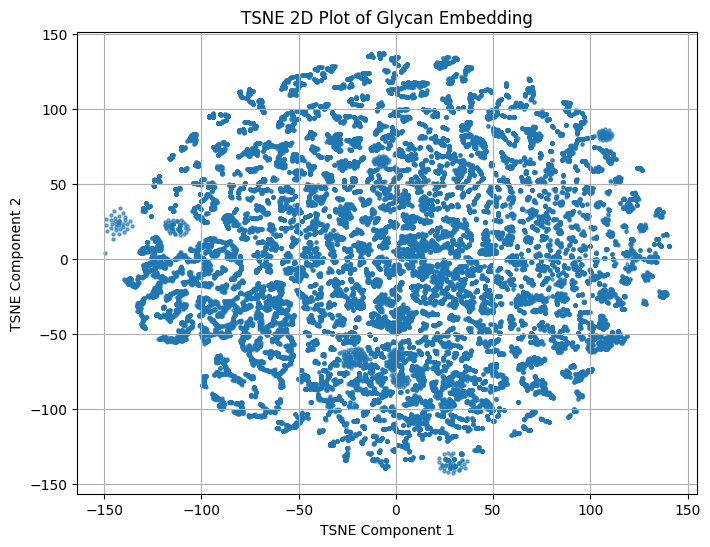

Shape of Final Matrix after PCA/SVD/TSNE/no reduction: (50589, 2)


(                                                             0          1
 glycan                                                                   
 Gal(b1-4)Glc-ol                                     125.698265  22.843784
 Neu5Ac(a2-3)Gal(b1-4)Glc1Cer                         87.335678   5.825486
 Glc1Cer                                              86.075142  -8.555442
 Gal(b1-4)GlcNAc(b1-2)Man(a1-3)[Gal(b1-4)GlcNAc(...   75.326279  28.698759
 Man(a1-2)Man(a1-3)[Man(a1-3)[Man(a1-6)]Man(a1-6...   75.442459  28.611843
 ...                                                        ...        ...
 Neu5Ac(a2-3)Gal(b1-4)GlcNAc(b1-2)[Neu5Ac(a2-6)G...  127.998085  21.475567
 Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-6)[Gal(b1-4)GlcN...  127.829796  21.365017
 Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)[Neu5Ac(a2-6)G...  127.977913  21.455719
 Neu5Ac(a2-3)Gal(b1-4)GlcNAc(b1-2)[Neu5Ac(a2-6)G...  127.977730  21.455732
 Neu5Ac(a2-3)Gal(b1-4)GlcNAc(b1-2)[Gal(b1-4)GlcN...  128.151230  21.564203
 
 [50589 rows x 2 column

In [11]:
# t-SNE visualization of our best embedding space
choose_embedding_method_2(None, 'TSNE', 2, df_glycan2, best_embedding)

The t-SNE projection shows the main cloud of glycans characterized by many tight clusters, suggesting the embedding has begun to separate out distinct subgroups, i.e. functionally similar glycans, from the bulk.

## Part 2: Embed our glycans
After finding a satisfying embedding space in **Part 1**, we embed our discovered glycans from `glycan_list`, and identify the glycans closest to our glycans of interest.

In [12]:
# Embed our glycans in the best embedding space

# Convert Composition column in glycan_list from stirng to dict
glycan_list['Composition'] = glycan_list['Composition'].apply(ast.literal_eval)
glycan_list = glycan_list.set_index('glycan') # change structure to correspond to df_glycan2_foi's structure

# Select only the features of interest
df_glycan2_foi = df_glycan2[['Composition', 'tissue_species', 'tissue_sample']]

# Concatenate the two dataframes along rows
df_combined = pd.concat([df_glycan2_foi, glycan_list], axis=0)

# Sanity check: ensure row counts sum up correctly
print(f"Sanity Check: {df_combined.shape[0] == (df_glycan2_foi.shape[0] + glycan_list.shape[0])}")

Sanity Check: True


In [13]:
# Embed our glycans

# Part 1: Embed sequences

# Step 1: Print the best sequence embedding technique
print(f"Best embedding technique for sequences: {methods_used_for_best_space['Sequence']}")

# Step 2: Preprocess glycan sequences into lists of glycoletters
# Use glycowork's min_process_glycans() to convert glycans sequence into a nested lists of glycoletters
df_combined['Processed Sequence'] = min_process_glycans(list(df_combined.index))

# Step 3: Convert glycoletter lists to space-separated strings, preparing input for TF-IDF
df_combined['Sequence_str'] = df_combined['Processed Sequence'].apply(lambda seq: ' '.join(seq))

# Step 4: Apply TF-IDF to the sequence strings
# Recover the TF-IDF model from the best embedding space
tfidf_vectorizer = methods_used_for_best_space['Sequence'][0]
X_tfidf = tfidf_vectorizer.fit_transform(df_combined['Sequence_str'])
embeddings_tfidf = X_tfidf.toarray()

# Create DataFrame for TF-IDF embeddings
temp_emb = pd.DataFrame(
    embeddings_tfidf,
    index=df_combined.index,
    columns=tfidf_vectorizer.get_feature_names_out()
    )

# Step 7: Reduce dimensionality of TF-IDF embeddings using PCA
# Recover the PCA model from the best embedding space
pca = methods_used_for_best_space['Sequence'][1]
reduced = pca.fit_transform(temp_emb)

# Step 8: Create final sequence embedding dataframe
seq_emb = pd.DataFrame(reduced, index=df_combined.index)
print(f'Shape: {seq_emb.shape}')

Best embedding technique for sequences: [TfidfVectorizer(), PCA(n_components=2, random_state=42)]
Shape: (50594, 2)


In [14]:
# Part 2: Embed Compositions using One-Hot encoding
print(f"Best embedding technique for compositions: {methods_used_for_best_space['Composition']}")
comp_emb, time_comp, _ = one_hot_embedding('Composition', df_combined)
print(f'Shape: {comp_emb.shape}')

Best embedding technique for compositions: ['One-Hot', None]
Shape: (50594, 15)


In [15]:
# Part 3: Embed Species of origin
print(f"Best embedding technique for species: {methods_used_for_best_space['Species']}")

# Step 1: Convert species lists into space-separated strings
df_combined['Species_str'] = df_combined['tissue_species'].apply(lambda seq: ' '.join(seq))

# Step 2: vectorize species strings with TF-IDF
# Recover the TF-IDF model chosen for species embedding
tfidf_vectorizer = methods_used_for_best_space['Species'][0] # recover model of the best embedding space
X_tfidf = tfidf_vectorizer.fit_transform(df_combined['Species_str'])
embeddings_tfidf = X_tfidf.toarray()

# Step 3: Build a DataFrame of TF-IDF features for species
temp_emb = pd.DataFrame(
    embeddings_tfidf,
    index=df_combined.index,
    columns=tfidf_vectorizer.get_feature_names_out()
    )

# Step 4: Reduce dimensionality with PCA
# Recover PCA model chosen for species embedding
pca = methods_used_for_best_space['Species'][1] # recover model of the best embedding space
reduced = pca.fit_transform(temp_emb)

# Step 5: Create the final species embedding DataFrame
spec_emb = pd.DataFrame(reduced, index=df_combined.index)
print(f'Shape: {spec_emb.shape}')

Best embedding technique for species: [TfidfVectorizer(), PCA(n_components=10, random_state=42)]
Shape: (50594, 10)


In [16]:
# Part 4: Embed Tissue origin using One-Hot Encoding
print(f"Best embedding technique for tissue: {methods_used_for_best_space['Tissue']}")

tissue_emb, time_tissue, _ = one_hot_embedding('Tissue', df_combined)
print(f'Shape: {tissue_emb.shape}')

Best embedding technique for tissue: ['One-Hot', None]
Shape: (50594, 269)


In [17]:
# Combine all embedding matrices and normalize them
embeddings_list = [seq_emb, comp_emb, tissue_emb, spec_emb]
our_glycans_embedded = combine_and_normalize_embeddings(embeddings_list, df_combined.index)

### Part 3: Enrich our glycans with Disease Association

The goal of this part is to enrich our glycans with information, i.e. providing new information and insights on our discovered glycans.

For this purpose, we try to predict the diseases the glycans can be associated to.

#### Part 3A: Fit a cosine-distance NearestNeighbors model to find each our glycans closest neighbors in the embedding space

This is the process we follow to predict the diseases our glycans are associated to:
1. We pull out the emebdding vectors for our glycans of interest and for the entire glycan library
2. We fit a cosine-distance NearestNeighbors model to find each of our query glycans' 20 closest neighbors in the full embedding. Cosine Similarity is the most common and appropriate metric for embedding spaces. It measures the angle between two vectors, making it less sensitive to absolute magnitude, and it is ideal for high-dimensional, normalized embedding spaces like ours. We don't use Euclidean distance because in high-dimensional, normalized spaces, it becomes less interpretable and more affected by magnitude rather than relative orientation of vectors.
3. For each query glycan, we exclude itself and any other "our glycans" from its neighbor list
3. We record the remainng neighbors and retrieve their disease associations (if any)
4. We plot the query glycan (red), its neighbors (blue), and the background cloud of all glycans in embedding space
4. If neighbor disease data exists, we show a bar chart of the most frequent diseases. Otherwise, we skip that panel and log a message.

For glycan Fuc(a1-?)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)[Fuc(a1-6)]GlcNAc, only 16 neighbors were kept.


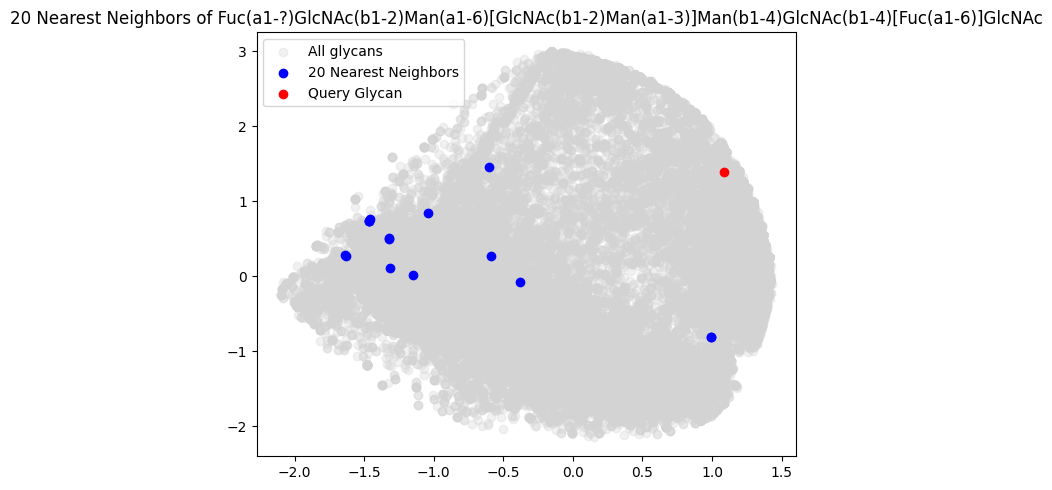

No disease association data available for neighbors of glycan Fuc(a1-?)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)[Fuc(a1-6)]GlcNAc. Skipping disease plot.

For glycan Neu5Ac(a2-?)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)[Fuc(a1-6)]GlcNAc, only 16 neighbors were kept.


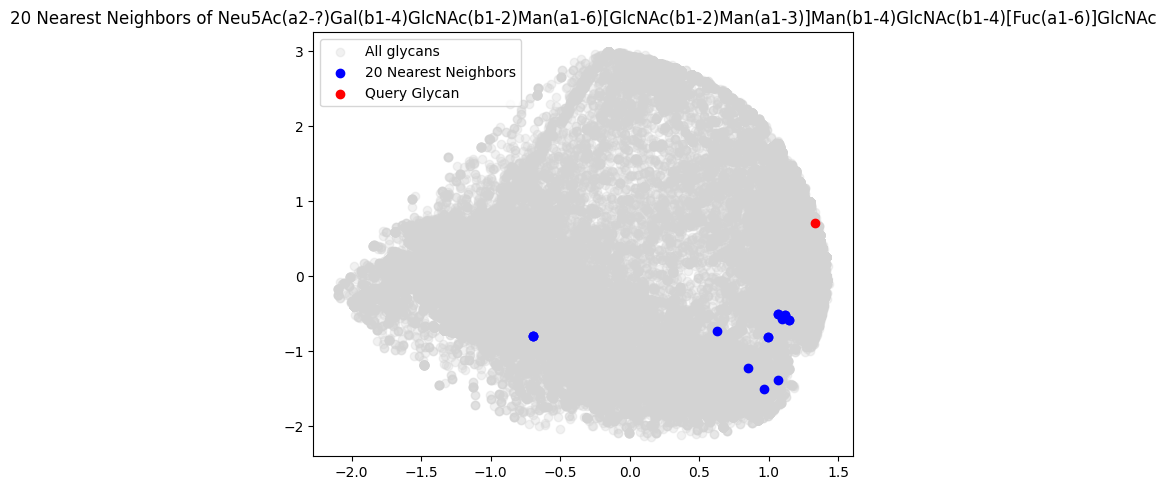

No disease association data available for neighbors of glycan Neu5Ac(a2-?)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)[Fuc(a1-6)]GlcNAc. Skipping disease plot.

For glycan Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal(b1-4)GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)GlcNAc, only 16 neighbors were kept.


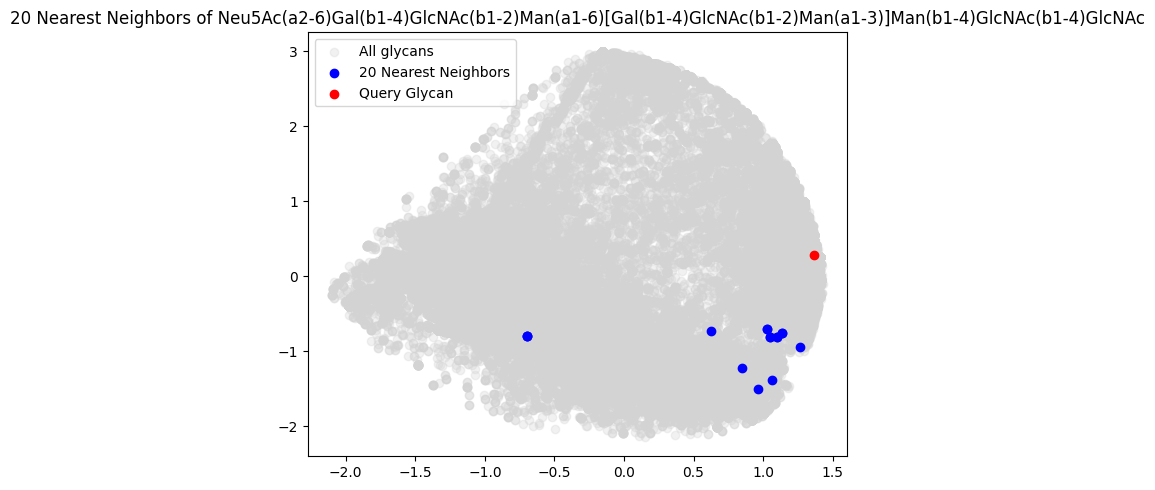

No disease association data available for neighbors of glycan Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal(b1-4)GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)GlcNAc. Skipping disease plot.

For glycan Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)GlcNAc, only 16 neighbors were kept.


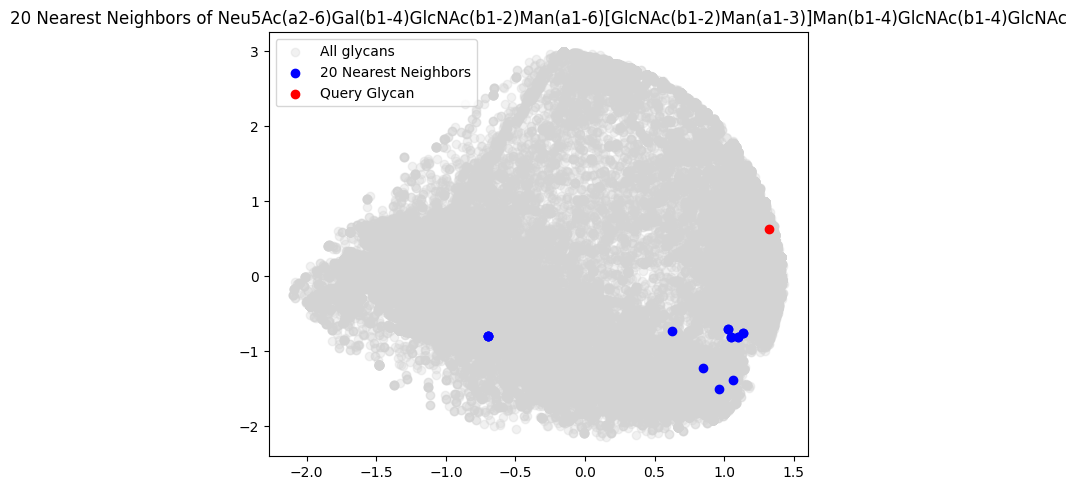

No disease association data available for neighbors of glycan Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)GlcNAc. Skipping disease plot.

For glycan Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal(b1-4)GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)GlcNAc, only 16 neighbors were kept.


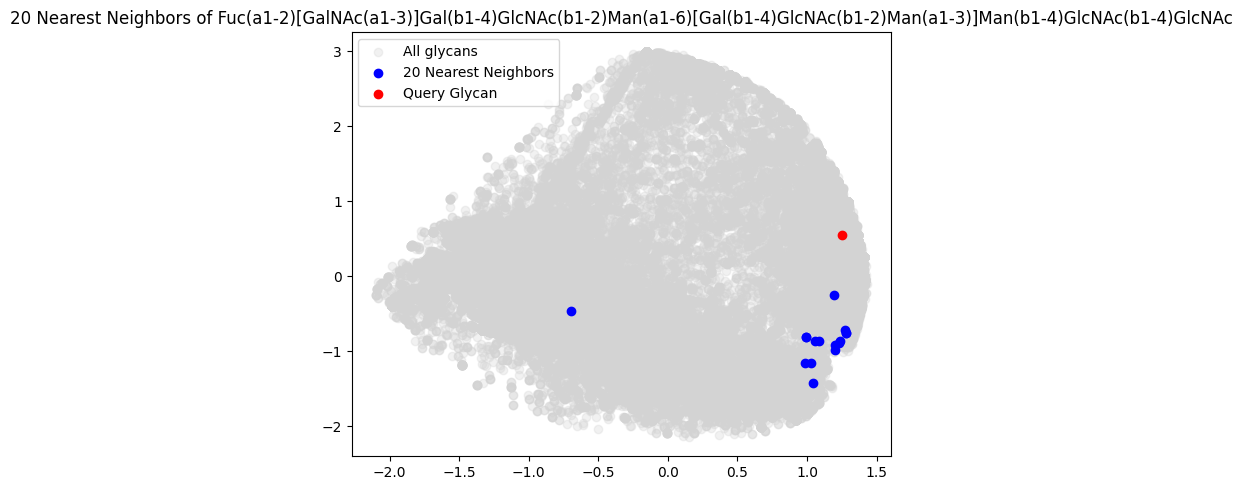

No disease association data available for neighbors of glycan Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal(b1-4)GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)GlcNAc. Skipping disease plot.



In [18]:
# Extract embeddings for our glycans and others
our_glycans = glycan_list.index
X_query = our_glycans_embedded.loc[our_glycans].values # our glycans
X_pool = our_glycans_embedded.values # all glycans (including ours)
index_pool = our_glycans_embedded.index

# Fit Nearest Neighbors using cosine distance
k = 20 # number of neighbors
nbrs = NearestNeighbors(n_neighbors=k+1, metric='cosine') # n_neighbors = 6 to get 5 nearest + self
nbrs.fit(X_pool)

# Find nearest neighbors
distances, indices = nbrs.kneighbors(X_query)

# Create a mapping for each of your glycans to its top 5 nearest neighbors (excluding itself)
closest_glycans = {}

# Loop through each glycan and plot
for i, glycan in enumerate(our_glycans):
    neighbor_ids = indices[i][1:]  # skip self
    neighbors = index_pool[neighbor_ids]
    
    filtered_neighbors = []
    # Skip neighbors that are our glycans
    for n in neighbors:
        if n in df_glycan2.index:
            filtered_neighbors.append(n)
    
    print(f"For glycan {glycan}, only {len(filtered_neighbors)} neighbors were kept.")
    
    closest_glycans[glycan] = filtered_neighbors # Save the closest neighbors to each glycans
    
    # Subset for plotting
    coords = our_glycans_embedded.loc[filtered_neighbors]
    coords_main = our_glycans_embedded.loc[glycan].to_frame().T
    
    # Disease association
    diseases = df_glycan2.loc[filtered_neighbors, "disease_association"]
    disease_counts = diseases.value_counts()

    # Plotting
    if disease_counts.dropna().empty or all(d == [] or d == '' for d in diseases):
        fig, ax = plt.subplots(figsize=(6, 5))

        # Just embedding neighbors
        ax.scatter(our_glycans_embedded.iloc[:, 0], our_glycans_embedded.iloc[:, 1], color='lightgrey', alpha=0.3, label='All glycans')
        ax.scatter(coords.iloc[:, 0], coords.iloc[:, 1], color='blue', label='20 Nearest Neighbors')
        ax.scatter(coords_main.iloc[:, 0], coords_main.iloc[:, 1], color='red', label='Query Glycan')
        ax.set_title(f'20 Nearest Neighbors of {glycan}')
        ax.legend()

        plt.tight_layout()
        plt.show()

        print(f"No disease association data available for neighbors of glycan {glycan}. Skipping disease plot.\n")
    else:
        fig, axs = plt.subplots(1, 2, figsize=(8, 2))

        # Embedding neighbors
        axs[0].scatter(our_glycans_embedded.iloc[:, 0], our_glycans_embedded.iloc[:, 1], color='lightgrey', alpha=0.3, label='All glycans')
        axs[0].scatter(coords.iloc[:, 0], coords.iloc[:, 1], color='blue', label='20 Nearest Neighbors')
        axs[0].scatter(coords_main.iloc[:, 0], coords_main.iloc[:, 1], color='red', label='Query Glycan')
        axs[0].set_title(f'20 Nearest Neighbors of {glycan}')
        axs[0].legend()

        # Disease association distribution
        sns.barplot(x=disease_counts.index, y=disease_counts.values, ax=axs[1])
        axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=45, ha='right')
        axs[1].set_title(f'Disease Association of Neighbors')
        axs[1].set_ylabel('Count')

        plt.tight_layout()
        plt.show()

Here are key observations from the plots:
1. Embedding Space Evaluation
- Except for the first glycan, each of our glycans is decently grouped with its neighbors, suggesting the embedding preserves local similarity well.
2. Consistent Retention of 16 nearest neighbors instead of 20:
- Each glycan from our glycans (`glycan_list`) retrieves 16 nearest neighbors instead of 20. 
- This is because the 4 missing neighbors are other glycans from `glycan_list`, which were excluded by design to avoid self-comparisons and circular information. 
- It confirms that our discovered glycans are closed to each other in the embedding space.
3. Absence of Disease Association among neighbors:
- For each gylcan, none of its neighbors have a known `disease_association` in `df_glycan2`.
- This indicates that disease annotation is sparse in our dataset, meaning this approch cannot be used to infer disease context for glycan_list using nearest neighbors, as the signal just isn't there.

The implications for disease association analysis are:
- The embedding has satisfying quality, allowing for clustering, visualization, and downstream prediction tasks.
- Using kNN in the embedding space to infer disease association fails due to sparsity of annotated neighbors.
- An alternative strategy would be to **enrich** our glycan information by several methods discussed in **Part 3B**.

### Part 3B: Predict Disease Association

As discussed before, we have disease association information for a subset of glycans in `df_glycan2`. Since the strategy we folloed in **Part 3A** is not enough to predict the diseases our glycans are associated to, we investigate a new strategy. 

The strategy we use is clustering and label propagatinon. We cluster glycans based on their embeddings and inspect whether any cluster is enriched for disease-associated glycans, then propagate disease labels within clusters.

This is the process we follow:
1. Prepare the "Disease" column: We iterate through all of our glycans. For our glycans, we set their disease_association to []. For other glycans, we pull their disease associations from `df_glycan2`. As mentioned before, some of them have empty lists [] (their either have no disease associated to them or we just don't have the information), and others have a list of the diseases they are associated to.
2. Cluster the combined embedding: we fit different clustering algorithms (GMM, K-Means, DBSCAN, Agglomerative clustering) on our glycan embeddings, record each glycan's cluster label, and compute silhoeutte and Calinksi-Harabsz scores to compare how well each method parititons the data.
3. Propagate disease labels by cluster: using the clustering assignments of the best clustering method, we gather all known diseases with each cluster, pick the top 5 most frequent, and assign that disease list to any glycans in the same cluster that originally had no annotations. Finally, we extract our discovered glycans' inferred disease lists, and plot the associations.

The clusterig methods we use are:
- **Gaussian Mixture Model (GMM)**: Fits the data as a weighted sum of Gaussian distirbutions, yeilding soft cluster memberships. It can model clusters with different shapes, sizes and orientations.
- **KMeans**: Partitions points into k hard clusters by minimizing the sum of squared distances to cluster centroids. Assumes roughly spherical, equal-variance clusters. 
- **DBSCAN**: Density-based clustering that groups points with many nearby neighbors and labels low-density points as noise. It can find arbitrarily shaped clusters without pre-specifying their number.
- **Agglomerative Clustering**: A bottom-up hierarchical approach that starts with each point as its own cluster and repeatedly merges the closest paris until reaching k clusters. Captures nested cluster structure.

The metrics we use for clustering evaluation are:
- Silhouette Score: Measures how well each point lies within its cluster vs the nearest other cluster. Ranges from -1 to +1, where higher means tighter, better-separatd clusters.
- Calinski-Harabasz Index: Ratio of between-cluster dispersion to within-cluster dispersion. A higher value indicates more distinct and compact clusters.

In [19]:
disease_associations = []
for index, row in df_combined.iterrows():
    if index in our_glycans:
        disease_associations.append([])
    else:
        disease_associations.append(df_glycan2.loc[index]['disease_association'])

df_combined['Disease'] = disease_associations

In [ ]:
# Store clustering results
results = {}

# GMMs
print('-------------GMM START----------------------------------')
gmm = GaussianMixture(n_components=5, random_state=42)
df_combined['cluster_gmm'] = gmm.fit_predict(our_glycans_embedded)
results['GMM'] = {
    'labels': df_combined['cluster_gmm'],
    'silhouette': silhouette_score(our_glycans_embedded, df_combined['cluster_gmm']),
    'calinski_harabasz': calinski_harabasz_score(our_glycans_embedded, df_combined['cluster_gmm'])
}
print('-------------GMM DONE-----------------------------------')

# KMeans
print('-------------KMeans START-------------------------------')
kmeans = KMeans(n_clusters=5, random_state=42)
df_combined['cluster_kmeans'] = kmeans.fit_predict(our_glycans_embedded)
results['KMeans'] = {
    'labels': df_combined['cluster_kmeans'],
    'silhouette': silhouette_score(our_glycans_embedded, df_combined['cluster_kmeans']),
    'calinski_harabasz': calinski_harabasz_score(our_glycans_embedded, df_combined['cluster_kmeans'])
}
print('-------------KMeans DONE--------------------------------')

# DBSCAN (no need to set number of clusters)
print('-------------DBSCAN START-------------------------------')
dbscan = DBSCAN(eps=1.5, min_samples=5, metric='cosine')
df_combined['cluster_dbscan'] = dbscan.fit_predict(our_glycans_embedded)

# Valid clusters = anything not -1
mask = df_combined['cluster_dbscan'] != -1
n_labels = len(set(df_combined.loc[mask, 'cluster_dbscan']))

if n_labels > 1:
    results['DBSCAN'] = {
        'labels': df_combined['cluster_dbscan'],
        'silhouette': silhouette_score(our_glycans_embedded[mask], df_combined.loc[mask, 'cluster_dbscan']),
        'calinski_harabasz': calinski_harabasz_score(our_glycans_embedded[mask], df_combined.loc[mask, 'cluster_dbscan'])
    }
else:
    print(f"DBSCAN failed to find at least 2 clusters (found {n_labels}).")
    results['DBSCAN'] = {'labels': df_combined['cluster_dbscan'], 'silhouette': None, 'calinski_harabasz': None}

print('-------------DBSCAN DONE-------------------------------')

# Agglomerative Clustering
print('-------------Agglomerative Clustering START-------------')
agglo = AgglomerativeClustering(n_clusters=5)
df_combined['cluster_agglo'] = agglo.fit_predict(our_glycans_embedded)
results['Agglomerative'] = {
    'labels': df_combined['cluster_agglo'],
    'silhouette': silhouette_score(our_glycans_embedded, df_combined['cluster_agglo']),
    'calinski_harabasz': calinski_harabasz_score(our_glycans_embedded, df_combined['cluster_agglo'])
}
print('-------------Agglomerative Clustering DONE--------------')

# Display metrics
print("\nClustering Evaluation Metrics:")
for method, res in results.items():
    print(f"\n{method}:")
    print(f"Silhouette Score: {res['silhouette']}")
    print(f"Calinski-Harabasz Index: {res['calinski_harabasz']}")

-------------GMM START----------------------------------
-------------GMM DONE-----------------------------------
-------------KMeans START-------------------------------
-------------KMeans DONE--------------------------------
-------------DBSCAN START-------------------------------
DBSCAN failed to find at least 2 clusters (found 1).
-------------DBSCAN DONE-------------------------------
-------------Agglomerative Clustering START-------------
-------------Agglomerative Clustering DONE--------------

Clustering Evaluation Metrics:

GMM:
Silhouette Score: 0.5146238895634379
Calinski-Harabasz Index: 1636.4767878010864

KMeans:
Silhouette Score: 0.09662505972326749
Calinski-Harabasz Index: 1582.0405486144357

DBSCAN:
Silhouette Score: None
Calinski-Harabasz Index: None

Agglomerative:
Silhouette Score: 0.9453936648673568
Calinski-Harabasz Index: 2742.711690902158


Among the four clustering methods tested, Agglomerative Clustering clearly outperforms the others with a silhouette score of 0.95 and the highest Calinski-Harabasz index (2743), indicating well-separated and cohesive clusters.
GMM shows moderate performance, while KMeans performs poorly, and DBSCAN fails to identify meaningful clusters.

We therefore retain the Agglomerative Clustering results for downstream disease association inference, as it provides the most reliable cluster structure in the embedding space.

In [21]:
# Create a copy to avoid modifying original
df_inferred = df_combined.copy()

# Infer diseases for glycans with no known associations
for cluster_id in df_inferred['cluster_agglo'].unique():
    cluster_members = df_inferred[df_inferred['cluster_agglo'] == cluster_id]
    
    # Separate those with and without disease info
    known_disease = cluster_members[cluster_members['Disease'].apply(lambda d: len(d) > 0)]
    unknown_disease = cluster_members[cluster_members['Disease'].apply(lambda d: len(d) == 0)]

    # Get all known diseases in this cluster
    all_diseases = known_disease['Disease'].explode()
    most_common = all_diseases.value_counts()
    
    # Skip if no known diseases in cluster
    if most_common.empty:
        continue
    
    # Assign top N diseases to glycans with missing info
    top_diseases = most_common.index[:5].tolist()  # pick top 5 most frequent diseases
    for glycan in unknown_disease.index:
        df_inferred.at[glycan, 'Disease'] = top_diseases

print("Disease inference complete.")

Disease inference complete.


Top disease associations for our glycans:
Disease
                      5
colorectal_cancer     5
pancreatic_cancer     5
cholangiocarcinoma    5
stomach_cancer        5
Name: count, dtype: int64


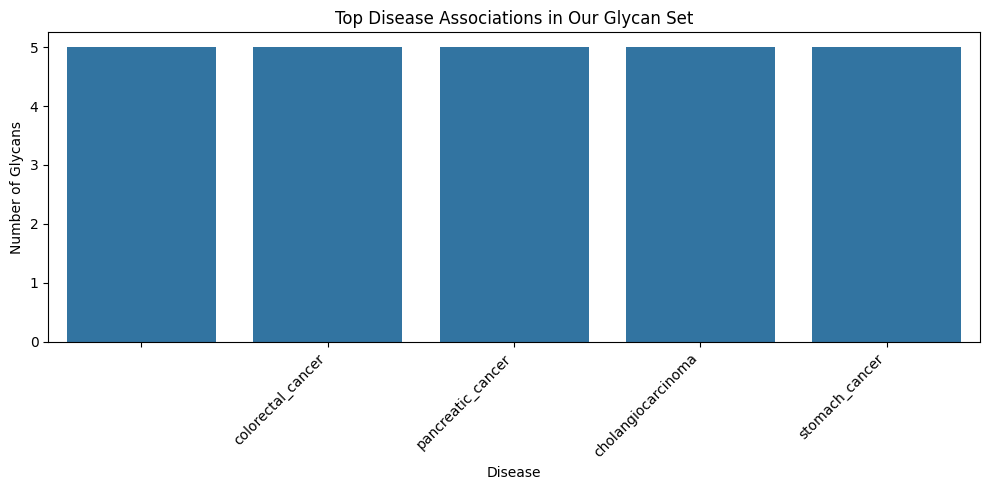

In [ ]:
# Subset the inferred dataframe
our_glycans_disease = df_inferred.loc[our_glycans, 'Disease']

# Flatten the list of diseases and count occurrences
disease_counts = our_glycans_disease.explode().value_counts()

# Display top diseases
print("Top disease associations for our glycans:")
print(disease_counts.head(10))  # Top 10 diseases

# Barplot

plt.figure(figsize=(10, 5))
sns.barplot(x=disease_counts.index[:10], y=disease_counts.values[:10])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of Glycans")
plt.title("Top Disease Associations in Our Glycan Set")
plt.tight_layout()
plt.show()

The bar chart shows that the diseases inferred to our glycans are: colorectal cancer, pancreatic cancer, cholangiocarcinoma and stomach cancer. Since our glycans are close in the embedding space (as seen in previous plots), it makes sense that we inferred the same diseases to all 5 glycans.

Now that we have disease association information for all of our glycans, including our discovered molecules, we learn our embedding space using the same methods as before for sequence, composition, species and tissue, but we add disease association. To do this, we investigate several methods of embedding for disease and choose those that lead to the best embedding space. The methods we try are the same as describes before (in **Part 1**).

In [23]:
df_inferred = df_inferred.drop(['cluster_agglo', 'cluster_gmm', 'cluster_kmeans', 'cluster_dbscan', 'Processed Sequence', 'Sequence_str', 'Species_str'], axis=1)
df_inferred.rename(columns={'Disease': 'disease_association'}, inplace=True)
df_inferred.to_csv('df_inferred.csv')

Embedding name: Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_One-Hot-None-None
Features used: {'Sequence': ['TF-IDF', 'PCA', 2], 'Composition': ['One-Hot', None, None], 'Species': ['TF-IDF', 'PCA', 10], 'Tissue': ['One-Hot', None, None], 'Disease': ['One-Hot', None, None]}
--------------------------------Sequence START--------------------------------
------------TF-IDF DONE
Shape of Matrix after embedding: (50594, 2008)
------------PCA DONE
Shape of Final Matrix after PCA/SVD/TSNE/no reduction: (50594, 2)
--------------------------------Sequence DONE--------------------------------
--------------------------------Composition START--------------------------------
------------One-Hot DONE
Shape of Matrix after embedding: (50594, 15)
------------NO REDUCTION
Shape of Final Matrix after PCA/SVD/TSNE/no reduction: (50594, 15)
--------------------------------Composition DON--------------------------------
--------------------------------Species START

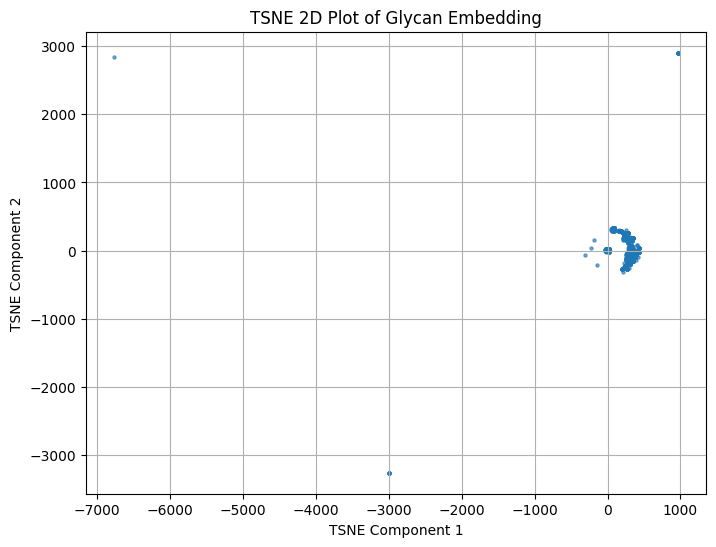

Shape of Final Matrix after PCA/SVD/TSNE/no reduction: (50594, 2)
--------------------------------Disease DONE--------------------------------


,Sequence_TF-IDF_PCA,Composition_One-Hot_None,Species_TF-IDF_PCA,Tissue_One-Hot_None,Disease_One-Hot_None,Disease_TF-IDF_PCA,Disease_TF-IDF_SVD,Disease_TF-IDF_TSNE,Silhouette Score,NN Purity,Time (s),Methods,Embedding Matrix
Embedding Name,,,,,,,,,,,,,
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_One-Hot-None-None,1,1,1,1,1,0,0,0,0.591,0.117,3.96,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_TF-IDF-PCA-2,1,1,1,1,0,1,0,0,0.533,0.108,1.92,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_TF-IDF-PCA-5,1,1,1,1,0,1,0,0,0.544,0.112,1.92,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_TF-IDF-PCA-10,1,1,1,1,0,1,0,0,0.544,0.112,1.89,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_TF-IDF-PCA-50,1,1,1,1,0,1,0,0,0.569,0.112,1.93,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_TF-IDF-SVD-2,1,1,1,1,0,0,1,0,0.533,0.108,1.93,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_TF-IDF-SVD-5,1,1,1,1,0,0,1,0,0.544,0.112,1.91,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_TF-IDF-SVD-10,1,1,1,1,0,0,1,0,0.543,0.112,2.09,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_TF-IDF-SVD-50,1,1,1,1,0,0,1,0,0.569,0.112,2.45,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...


In [ ]:
# Disease Methods

embedding_names = []
feature_dicts = []

# Define options for each feature
seq_method = ('TF-IDF', 'PCA', 2)
comp_method = ('One-Hot', None, None)
spec_method = ('TF-IDF', 'PCA', 10)
tiss_method = ('One-Hot', None, None)
disease_methods = [('One-Hot', None, None), ('TF-IDF', 'PCA', 2), ('TF-IDF', 'PCA', 5), ('TF-IDF', 'PCA', 10), ('TF-IDF', 'PCA', 50), ('TF-IDF', 'SVD', 2), ('TF-IDF', 'SVD', 5), ('TF-IDF', 'SVD', 10), ('TF-IDF', 'SVD', 50)]

# Loop through all combinations
for dis_method in disease_methods:
         
    # Build feature dictionary
    feature_dict = {
        'Sequence': list(seq_method),
        'Composition': list(comp_method),
        'Species': list(spec_method),
        'Tissue': list(tiss_method),
        'Disease': list(dis_method)
    }
    
    # Create a readable name
    name = f"Sequence_{seq_method[0]}-{seq_method[1]}-{seq_method[2]}_Composition_{comp_method[0]}_Species_{spec_method[0]}-{spec_method[1]}-{spec_method[2]}_Tissue_{tiss_method[0]}_Disease_{dis_method[0]}-{dis_method[1]}-{dis_method[2]}"
    
    # Save
    feature_dicts.append(feature_dict)
    embedding_names.append(name)

summary_df7 = compare_embeddings(embedding_names, feature_dicts, df_inferred, N_glycans_df)
summary_df7

1. Does Disease assocation improve the embedding space?

Before adding disease, the silhouette score and nearest neighbord purity of the best embedding space were 0.529 and 0.121. The best embedding space after adding disease yields score of 0.591 and 0.117. Adding disease association improved global structure (better-defined clusters) but had minimal impact on local neighborhood coherence. The embedding is more structured overall.

2. Which Disease embedding space is the best?
- Disease-One-Hot without reduction yields the best silhouette score: 0.591, indicating that the embedding has well-separated and compact clusters, reflecting strong global structure. I also yields the best nearest neighbord purity: 0.117, which is modest, but still the highest observed.

In summary, adding disease association improves both clustering structure, confirming it is a meaningful feature, even though it has minimal impact on neighborhood structure. One-Hot encoding without reduction performs best.

Starting from now, the embedding space we will use is:
- Sequence: TF-IDF with 2-component PCA
- Composition: One-Hot with no reduction
- Species: TF-IDF with 10-component PCA
- Tissue: One-Hot with no reduction
- Disease: One-Hot with no reduction

In [ ]:
# Disease Methods

# Define options for each feature
seq_method = ('TF-IDF', 'PCA', 2)
comp_method = ('One-Hot', None, None)
spec_method = ('TF-IDF', 'PCA', 10)
tiss_method = ('One-Hot', None, None)
dis_method = ('One-Hot', None, None)

# Build feature dictionary
feature_dict = {
    'Sequence': list(seq_method),
    'Composition': list(comp_method),
    'Species': list(spec_method),
    'Tissue': list(tiss_method),
    'Disease': list(dis_method)
}

# Create a readable name
name = f"Sequence_{seq_method[0]}-{seq_method[1]}-{seq_method[2]}_Composition_{comp_method[0]}_Species_{spec_method[0]}-{spec_method[1]}-{spec_method[2]}_Tissue_{tiss_method[0]}_Disease_{dis_method[0]}"

best_embedding_summary = compare_embeddings([name], [feature_dict], df_inferred, N_glycans_df)

Embedding name: Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_One-Hot
Features used: {'Sequence': ['TF-IDF', 'PCA', 2], 'Composition': ['One-Hot', None, None], 'Species': ['TF-IDF', 'PCA', 10], 'Tissue': ['One-Hot', None, None], 'Disease': ['One-Hot', None, None]}
--------------------------------Sequence START--------------------------------
------------TF-IDF DONE
Shape of Matrix after embedding: (50594, 2008)
------------PCA DONE
Shape of Final Matrix after PCA/SVD/TSNE/no reduction: (50594, 2)
--------------------------------Sequence DONE--------------------------------
--------------------------------Composition START--------------------------------
------------One-Hot DONE
Shape of Matrix after embedding: (50594, 15)
------------NO REDUCTION
Shape of Final Matrix after PCA/SVD/TSNE/no reduction: (50594, 15)
--------------------------------Composition DON--------------------------------
--------------------------------Species START----------

In [26]:
methods_used_for_best_space = best_embedding_summary.loc['Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_One-Hot']['Methods']

print(f'The methods used to get the best embedding space are: {methods_used_for_best_space}')

The methods used to get the best embedding space are: {'Sequence': [TfidfVectorizer(), PCA(n_components=2, random_state=42)], 'Composition': ['One-Hot', None], 'Species': [TfidfVectorizer(), PCA(n_components=10, random_state=42)], 'Tissue': ['One-Hot', None], 'Disease': ['One-Hot', None]}


### Part 3C: Add Protein-Glycan Bindings

In this section, we do the same process as for disease. `glycan_binding` contains protein-glycan binding interactions but only for certain glycans. For this reason, we follow the same process as before to infer protein-glycan binding interactions to the glycans that did not have the information before.

To do this, we follow a specific process:

1. Cluster the glycans using the embedding space
- We take our original `glycan_binding` table, keep only the columns corresponding to glycans and the `protein` column, set `protein` as the row index and transpose so that rows are glycans, then fill missing values with 0.
- Compare the glycan indices in that binding matrix to those in our combined glycan dataframe, add a binary “Has Protein–Glycan Binding Information” column, and then join the full binding matrix in.
- Use our best embedding space so far (after including disease association) to run clustering algorithms: **Gaussian Mixture Model** (5 components), **K-Means** (5 clusters), **DBSCAN** (ε = 1.5, min_samples = 5, cosine distance), and **Agglomerative Clustering** (5 clusters).  
- For each, store the cluster labels on `df_complete` and compute two validation metrics:  
    - **Silhouette Score** (how well‐separated the clusters are) 
    - **Calinski–Harabasz Index** (ratio of between‐cluster to within‐cluster dispersion).
- Compare results to determine the best clustering method.

Once we identify the best clustering method, we use the fact that glycans which fall into the same cluster have similar characteristics to impute any missing protein-glycan interactions.
 
2. Infer Protein-Glycan Binding Interactions 
- We identify which columns in our dataframe correspond to proteins
- For each cluster, we split its members into those with measured binding data and those without.
- For every protein feature, we compute the mean binding strength across the "knwon" glycans in that cluster and assign that cluster-specific average to all "unknown" glycans. 

This way, every glycan in the dataset ends up with a complete binding profile, filled in by the most representative values from its own cluster.

In [ ]:
# Make a copy of the original glycan–protein binding DataFrame
glycan_binding2 = glycan_binding.copy()

# Select the first 2 635 columns (correspond to glycans)
glycan_columns = glycan_binding.columns[:2635]

# Keep only those glycan columns plus the 'protein' identifier
columns_to_keep = list(glycan_columns) + ['protein']
glycan_binding2 = glycan_binding2[columns_to_keep]

# Index the DataFrame by protein name
glycan_binding2 = glycan_binding2.set_index('protein')

# Transpose so that rows correspond to glycans and columns to proteins
glycan_binding2 = glycan_binding2.T

# Fill any missing binding values with 0 (no interaction)
glycan_binding2 = glycan_binding2.fillna(0)

In [28]:
# Step 1: Check overlap
matching = glycan_binding2.index.intersection(df_combined.index)
print(f"Matching glycans: {len(matching)} / {len(glycan_binding2.index)}")

Matching glycans: 1263 / 2635


In [29]:
# Step 2: Check examples of mismatches
not_matching = glycan_binding2.index.difference(df_combined.index)
print("Examples of unmatched glycans:")
print(not_matching[:5])

Examples of unmatched glycans:
Index(['3-Anhydro-Gal(a1-3)Gal(b1-4)3-Anhydro-Gal(a1-3)Gal4S',
       '3-Anhydro-Gal(a1-3)Gal4S(b1-4)3-Anhydro-Gal(a1-3)Gal4S',
       '3-Anhydro-Gal(a1-3)Gal4S(b1-4)3-Anhydro-Gal(a1-3)Gal4S(b1-4)3-Anhydro-Gal(a1-3)Gal4S',
       '3-Anhydro-Gal(a1-3)Gal4S(b1-4)3-Anhydro-Gal(a1-3)Gal4S(b1-4)3-Anhydro-Gal(a1-3)Gal4S(b1-4)3-Anhydro-Gal(a1-3)Gal4S',
       '3-Anhydro-Gal(a1-3)Gal4S(b1-4)3-Anhydro-Gal2S(a1-3)Gal4S(b1-4)3-Anhydro-Gal(a1-3)Gal4S'],
      dtype='object')


As we can see, only 1263 out of the 2635 glycans in `glycan_binding` are also in our glycan dataframe. We only keep those that are also in our dataframe.

In [ ]:
# Initialize a list to flag presence of protein–glycan binding data
has_pgb_interactions = []

# Iterate through each glycan in df_inferred
for glycan, _ in df_inferred.iterrows():
    # If glycan is in the binding DataFrame’s index, mark as having data
    if glycan in glycan_binding2.index:
        has_pgb_interactions.append(1)
    else:
        # Otherwise, mark as missing binding information
        has_pgb_interactions.append(0)

# Add the binary indicator column to df_inferred
df_inferred["Has Protein-Glycan Binding Information"] = has_pgb_interactions

# Join the protein–glycan binding matrix into the main DataFrame
df_complete = df_inferred.join(glycan_binding2)

In [ ]:
# Recover our best embedding method
best_embedding = best_embedding_summary.loc['Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_One-Hot']['Embedding Matrix']

What we will do now is clustering the glycans based on their sequence embeddings, and do clustering, to propagate the labels of glycan binding protein. We do this per protein.

In [32]:
df_complete = df_complete.copy()

# Store clustering results
results = {}

# GMMs
print('-------------GMM START----------------------------------')
gmm = GaussianMixture(n_components=5, random_state=42)
df_complete['cluster_gmm'] = gmm.fit_predict(best_embedding)
results['GMM'] = {
    'labels': df_complete['cluster_gmm'],
    'silhouette': silhouette_score(best_embedding, df_complete['cluster_gmm']),
    'calinski_harabasz': calinski_harabasz_score(best_embedding, df_complete['cluster_gmm'])
}
print('-------------GMM DONE-----------------------------------')

# KMeans
print('-------------KMeans START----------------------------------')
kmeans = KMeans(n_clusters=5, random_state=42)
df_complete['cluster_kmeans'] = kmeans.fit_predict(best_embedding)
results['KMeans'] = {
    'labels': df_complete['cluster_kmeans'],
    'silhouette': silhouette_score(best_embedding, df_complete['cluster_kmeans']),
    'calinski_harabasz': calinski_harabasz_score(best_embedding, df_complete['cluster_kmeans'])
}
print('-------------KMeans DONE-----------------------------------')

# DBSCAN (no need to set number of clusters)
print('-------------DBSCAN START-------------------------------')
dbscan = DBSCAN(eps=1.5, min_samples=5, metric='cosine')
df_complete['cluster_dbscan'] = dbscan.fit_predict(best_embedding)

# Valid clusters = anything not -1
mask = df_complete['cluster_dbscan'] != -1
n_labels = len(set(df_complete.loc[mask, 'cluster_dbscan']))

if n_labels > 1:
    results['DBSCAN'] = {
        'labels': df_complete['cluster_dbscan'],
        'silhouette': silhouette_score(best_embedding[mask], df_complete.loc[mask, 'cluster_dbscan']),
        'calinski_harabasz': calinski_harabasz_score(best_embedding[mask], df_complete.loc[mask, 'cluster_dbscan'])
    }
else:
    print(f"DBSCAN failed to find at least 2 clusters (found {n_labels}).")
    results['DBSCAN'] = {'labels': df_complete['cluster_dbscan'], 'silhouette': None, 'calinski_harabasz': None}

print('-------------DBSCAN DONE-------------------------------')

# Agglomerative Clustering
print('-------------Agglomerative Clustering START-------------')
agglo = AgglomerativeClustering(n_clusters=5)
df_complete['cluster_agglo'] = agglo.fit_predict(best_embedding)
results['Agglomerative'] = {
    'labels': df_complete['cluster_agglo'],
    'silhouette': silhouette_score(best_embedding, df_complete['cluster_agglo']),
    'calinski_harabasz': calinski_harabasz_score(best_embedding, df_complete['cluster_agglo'])
}
print('-------------Agglomerative Clustering DONE--------------')

# Display metrics
print("\nClustering Evaluation Metrics:")
for method, res in results.items():
    print(f"\n{method}:")
    print(f"Silhouette Score: {res['silhouette']}")
    print(f"Calinski-Harabasz Index: {res['calinski_harabasz']}")

-------------GMM START----------------------------------
-------------GMM DONE-----------------------------------
-------------KMeans START----------------------------------
-------------KMeans DONE-----------------------------------
-------------DBSCAN START-------------------------------
DBSCAN failed to find at least 2 clusters (found 1).
-------------DBSCAN DONE-------------------------------
-------------Agglomerative Clustering START-------------
-------------Agglomerative Clustering DONE--------------

Clustering Evaluation Metrics:

GMM:
Silhouette Score: 0.4443962131498501
Calinski-Harabasz Index: 1108.751503103334

KMeans:
Silhouette Score: 0.1805949349637309
Calinski-Harabasz Index: 1130.6448962392533

DBSCAN:
Silhouette Score: None
Calinski-Harabasz Index: None

Agglomerative:
Silhouette Score: 0.9442328713606291
Calinski-Harabasz Index: 2273.0407567647235


In [ ]:
# Identify columns that are not protein–glycan binding features
non_protein_cols = [
    "Composition",
    "tissue_species",
    "tissue_sample",
    "disease_association",
    "Has Protein-Glycan Binding Information",
    "cluster_gmm",
    "cluster_kmeans",
    "cluster_dbscan",
    "cluster_agglo",
]

# List all protein columns by excluding the above
protein_columns = [
    col for col in df_inferred.columns
    if col not in non_protein_cols
]

# For each agglomerative cluster, propagate mean PGB values to missing entries
for cluster_id in df_complete["cluster_agglo"].unique():

    # Subset the glycans in this cluster
    cluster_members = df_complete[
        df_complete["cluster_agglo"] == cluster_id
    ]

    # Known vs unknown PGB information
    known = cluster_members[
        cluster_members["Has Protein-Glycan Binding Information"] == 1
    ]
    unknown = cluster_members[
        cluster_members["Has Protein-Glycan Binding Information"] == 0
    ]

    # Calculate and assign the mean binding value per protein
    for protein in protein_columns:
        mean_value = known[protein].mean()
        df_complete.loc[unknown.index, protein] = mean_value

,Composition,tissue_species,tissue_sample,disease_association,Has Protein-Glycan Binding Information,TAL6-4LysM,rCnSL-proA,AntigenI/IIA3VP1,TAL6-6LysM,SP15308A-bot-339-19-339,...,tcdB-B2-1,Gal_3C,cov/mhv/MERS,chitinase 3-like protein 2,Vd2LysM,cov/MERS,cluster_gmm,cluster_kmeans,cluster_dbscan,cluster_agglo
glycan,,,,,,,,,,,,,,,,,,,,,
Gal(b1-4)Glc-ol,{'Hex': 2},"[Acinonyx_jubatus, Addax_nasomaculatus, Ailuro...","[milk, milk, milk, milk, milk, milk, milk, mil...","[, colorectal_cancer, pancreatic_cancer, chola...",0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3,3,0,1
Neu5Ac(a2-3)Gal(b1-4)Glc1Cer,"{'Neu5Ac': 1, 'Hex': 2}","[Homo_sapiens, Homo_sapiens, Homo_sapiens, Hom...","[A549_cell_line, AML_193_cell_line, CHOK1_cell...","[cataract, lung_small_cell_carcinoma, melanoma]",0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2,2,0,3
Glc1Cer,{'Hex': 1},"[Chlorocebus_sabaeus, Homo_sapiens, Mus_muscul...","[COS7_cell_line, HT29_cell_line, M1_cell_line,...",[melanoma],0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,0
Gal(b1-4)GlcNAc(b1-2)Man(a1-3)[Gal(b1-4)GlcNAc(b1-2)Man(a1-6)]Man(b1-4)GlcNAc(b1-4)[Fuc(a1-6)]GlcNAc,"{'Hex': 5, 'HexNAc': 4, 'dHex': 1}","[Homo_sapiens, Mus_musculus, Homo_sapiens, Hom...","[2A3_cell_line, A9_fibroblast_cell_line, BMMC_...","[Crohn_disease, Lyme_disease, colorectal_cance...",1,0.685388,0.558532,1.807711,-1.432792,-0.014128,...,0.000000,-0.219611,0.748234,0.000000,-1.272057,-0.783509,4,4,0,0
Man(a1-2)Man(a1-3)[Man(a1-3)[Man(a1-6)]Man(a1-6)]Man(b1-4)GlcNAc(b1-4)GlcNAc,"{'Hex': 6, 'HexNAc': 2}","[Homo_sapiens, Homo_sapiens, Cricetulus_griseu...","[2A3_cell_line, B_cell, CHOK1_cell_line, CHOS_...","[Toxoplasma_gondii_infection, chronic_low_back...",1,-1.280536,1.718850,0.367533,2.524406,0.003137,...,-0.305211,0.776192,2.549925,-0.256835,0.325568,1.672796,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fuc(a1-?)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)[Fuc(a1-6)]GlcNAc,"{'dHex': 2, 'HexNAc': 4, 'Hex': 3}",['Homo_sapiens'],['blood'],"[, colorectal_cancer, pancreatic_cancer, chola...",0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,1
Neu5Ac(a2-?)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)[Fuc(a1-6)]GlcNAc,"{'Neu5Ac': 1, 'Hex': 4, 'HexNAc': 4, 'dHex': 1}",['Homo_sapiens'],['blood'],"[, colorectal_cancer, pancreatic_cancer, chola...",0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,1
Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal(b1-4)GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)GlcNAc,"{'Neu5Ac': 1, 'Hex': 5, 'HexNAc': 4}",['Homo_sapiens'],['blood'],"[, colorectal_cancer, pancreatic_cancer, chola...",1,0.655827,-0.372519,-1.050066,0.106119,-0.140849,...,0.081687,-0.210601,1.075390,0.000000,0.410339,0.005899,1,1,0,1


Now that protein-glycan binding interactions were inferred, we visualize the protein-glycan binding interactions of our glycans of interest. First, we pull out the numeric protein-glycan columns from our ginal enriched dataframe and lay out a grid of subplots. For each glycan of interest, we:
- Filter out zero interactions
- Pick the top 10 proteins by absolute binding magnitude
- Sort them so the biggest bars sit at the top
- Draw a horizontal bar chart showing each protein's interaction value

If one of our glycans has no data (i.e. no interaction with any protein), we print "no data" instead of a blank chart.

In [ ]:
final_enriched_df = df_complete.copy()
final_enriched_df = final_enriched_df.fillna(0)

/var/folders/f6/p2jq7zvd7jq9y5mvqb6p1wlh0000gn/T/ipykernel_52396/1585598125.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/f6/p2jq7zvd7jq9y5mvqb6p1wlh0000gn/T/ipykernel_52396/1585598125.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


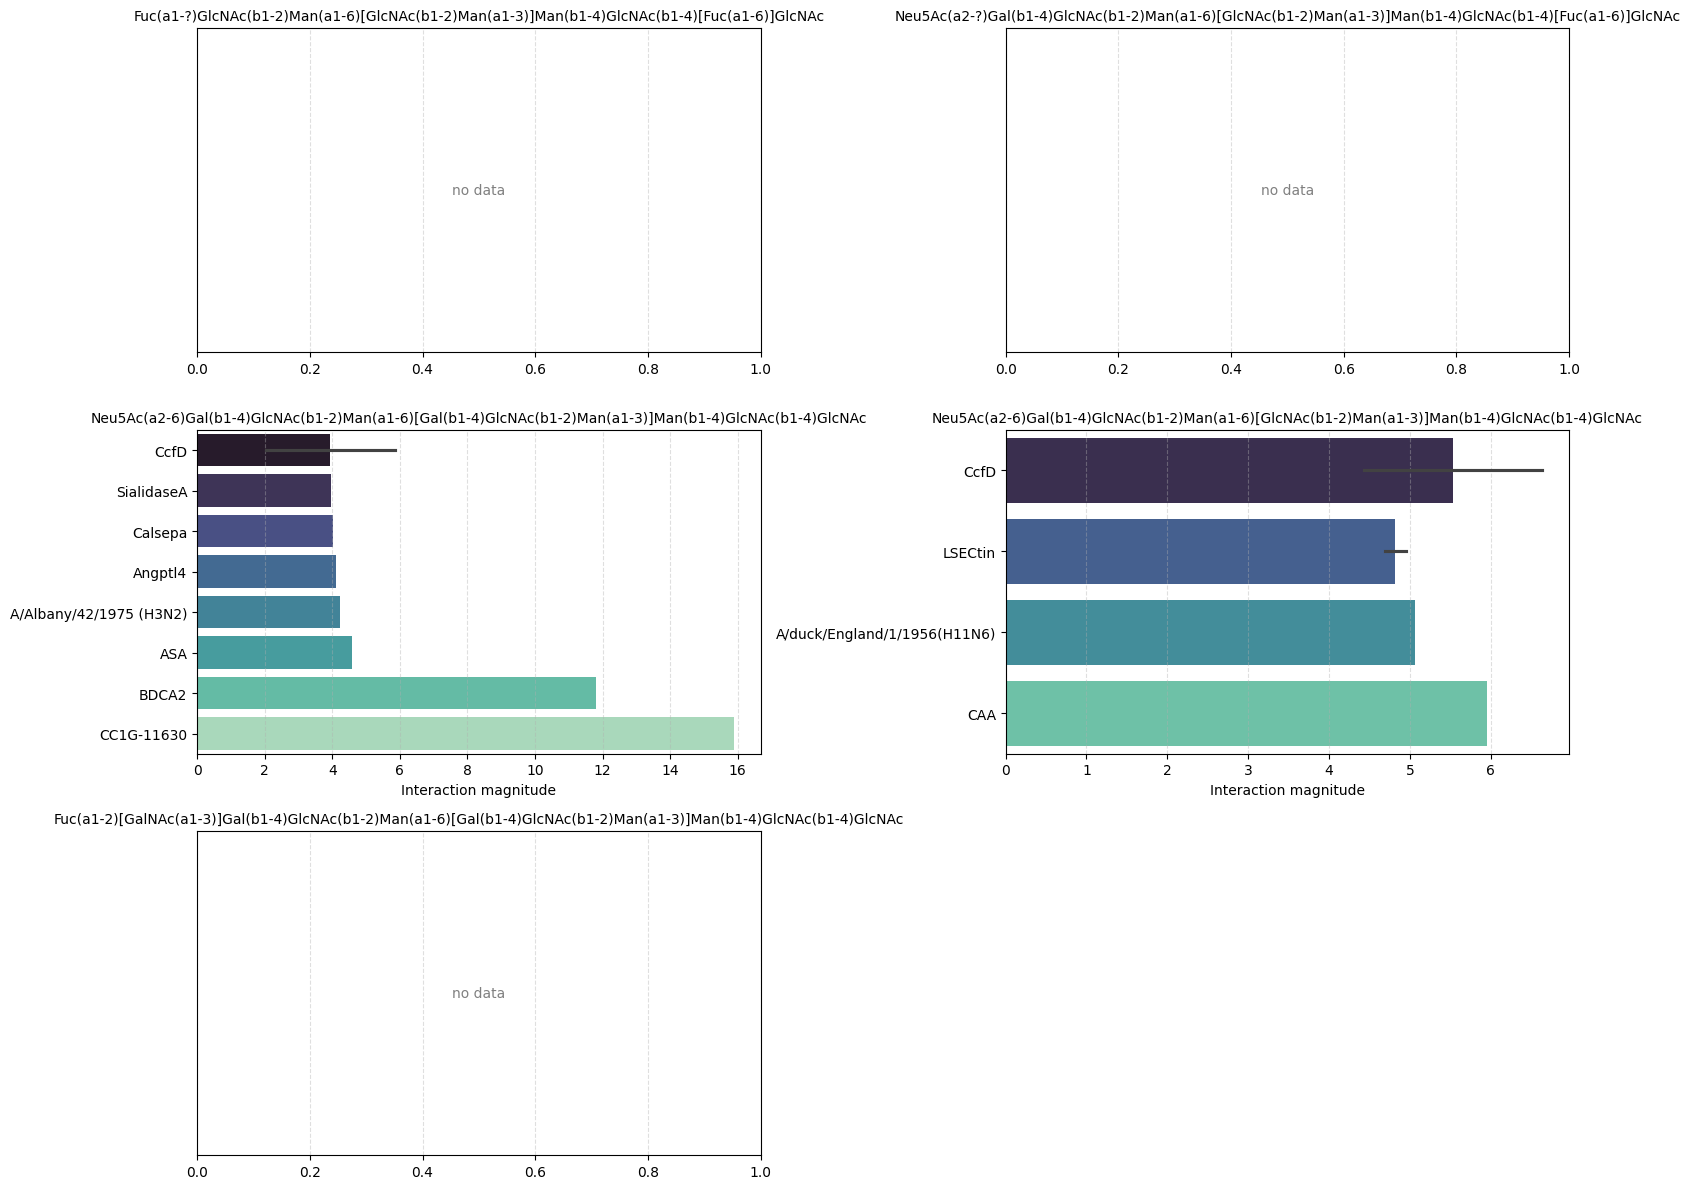

In [ ]:
# Only plot for our discovered glycans
glycans_of_interest = our_glycans  

# Identify our protein columns
non_protein = {
    'Composition', 'tissue_species', 'tissue_sample',
    'disease_association','Has Protein-Glycan Binding Information',
    'cluster_gmm','cluster_kmeans','cluster_dbscan','cluster_agglo'
}
protein_cols = [c for c in final_enriched_df.columns if c not in non_protein]

n = len(glycans_of_interest)
ncols = 2
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4), sharex=False)

for ax, glycan in zip(axes.flatten(), glycans_of_interest):
    vals = final_enriched_df.loc[glycan, protein_cols].dropna()
    vals = vals[vals != 0]
    if vals.empty:
        ax.text(0.5, 0.5, 'no data', ha='center', va='center', color='gray')
        ax.set_yticks([])
    else:
        # Pick top 10 by absolute value
        top10 = vals.abs().sort_values(ascending=False).head(10).index
        top_vals = vals.loc[top10].sort_values()  # sort so largest at top
        
        sns.barplot(
            x=top_vals.values,
            y=top_vals.index,
            ax=ax,
            palette='mako'
        )
        ax.set_xlabel('Interaction magnitude')
        ax.set_ylabel(None)
    ax.set_title(glycan, fontsize=10)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

# remove any empty subplots
for extra in axes.flatten()[n:]:
    fig.delaxes(extra)

plt.tight_layout()
plt.show()


The plots show us that only two of the five discovered glycans have any protein-binding interactions (obtained from the inferring):
- Neu5Ac(a2-6)Gal(b1-4)GlcNAc…Man(a1-4)GlcNAc binds most strongly to CC1G-11630 (~16 units) and BDCA2 (~12), with weaker interactions (≈4–5) for ASA, A/Albany/42/1975, Angptl4, Calsepa and SialidaseA.
- Neu5Ac(a2-6)Gal(b1-4)GlcNAc…Man(a1-6)[Gal…]GlcNAc shows moderate binding to CAA (~6), CcfD (~5.5), A/duck/England/1/1956 (~5) and LSEctin (~4.8).

Embedding name: Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_One-Hot_PGB_No Method-PCA-2
Features used: {'Sequence': ['TF-IDF', 'PCA', 2], 'Composition': ['One-Hot', None, None], 'Species': ['TF-IDF', 'PCA', 10], 'Tissue': ['One-Hot', None, None], 'Disease': ['One-Hot', None, None], 'Protein-Glycan Binding': ['No Method', 'PCA', 2]}
--------------------------------Sequence START--------------------------------
------------TF-IDF DONE
Shape of Matrix after embedding: (50594, 2008)
------------PCA DONE
Shape of Final Matrix after PCA/SVD/TSNE/no reduction: (50594, 2)
--------------------------------Sequence DONE--------------------------------
--------------------------------Composition START--------------------------------
------------One-Hot DONE
Shape of Matrix after embedding: (50594, 15)
------------NO REDUCTION
Shape of Final Matrix after PCA/SVD/TSNE/no reduction: (50594, 15)
--------------------------------Composition DON-----------------

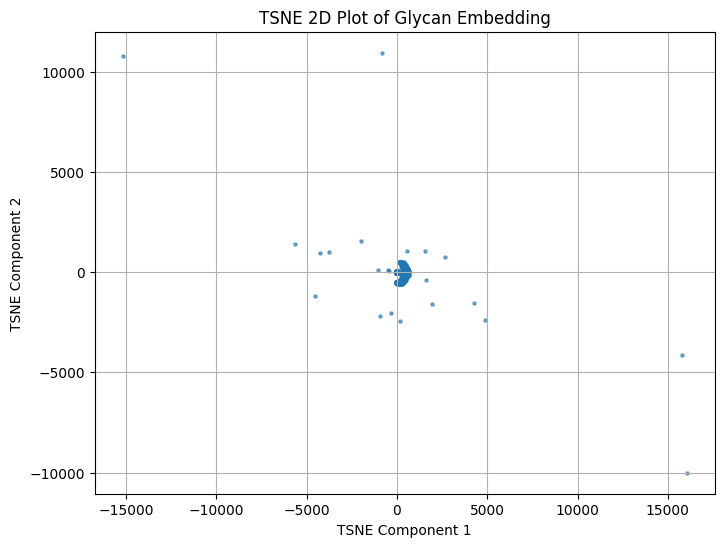

Shape of Final Matrix after PCA/SVD/TSNE/no reduction: (50594, 2)
--------------------------------Protein-Glycan DONE--------------------------------


,Sequence_TF-IDF_PCA,Composition_One-Hot_None,Species_TF-IDF_PCA,Tissue_One-Hot_None,Disease_One-Hot_None,Protein-Glycan Binding_No Method_PCA,Protein-Glycan Binding_No Method_SVD,Protein-Glycan Binding_No Method_TSNE,Silhouette Score,NN Purity,Time (s),Methods,Embedding Matrix
Embedding Name,,,,,,,,,,,,,
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_One-Hot_PGB_No Method-PCA-2,1,1,1,1,1,1,0,0,0.589,0.100,5.15,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_One-Hot_PGB_No Method-PCA-5,1,1,1,1,1,1,0,0,0.586,0.117,5.38,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_One-Hot_PGB_No Method-PCA-10,1,1,1,1,1,1,0,0,0.583,0.112,907.04,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_One-Hot_PGB_No Method-PCA-50,1,1,1,1,1,1,0,0,0.575,0.088,918.60,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_One-Hot_PGB_No Method-SVD-2,1,1,1,1,1,0,1,0,0.589,0.100,5.18,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_One-Hot_PGB_No Method-SVD-5,1,1,1,1,1,0,1,0,0.586,0.117,4.98,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_One-Hot_PGB_No Method-SVD-10,1,1,1,1,1,0,1,0,0.583,0.112,5.62,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_One-Hot_PGB_No Method-SVD-50,1,1,1,1,1,0,1,0,0.575,0.079,9.86,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...
Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_One-Hot_PGB_No Method-TSNE-2,1,1,1,1,1,0,0,1,0.590,0.100,6385.35,"{'Sequence': [TfidfVectorizer(), PCA(n_compone...",...


In [ ]:
# Protein-Glycan Binding interactions Embedding Methods

df_of_interest = final_enriched_df[protein_cols]

embedding_names = []
feature_dicts = []

# Define options for each feature
seq_method = ('TF-IDF', 'PCA', 2)
comp_method = ('One-Hot', None, None)
spec_method = ('TF-IDF', 'PCA', 10)
tiss_method = ('One-Hot', None, None)
dis_method = ('One-Hot', None, None)
pgb_methods = [('No Method', 'PCA', 2), ('No Method', 'PCA', 5), ('No Method', 'PCA', 10), ('No Method', 'PCA', 50), ('No Method', 'SVD', 2), ('No Method', 'SVD', 5), ('No Method', 'SVD', 10), ('No Method', 'SVD', 50)]

# Loop through all combinations
for pgb_method in pgb_methods:
         
    # Build feature dictionary
    feature_dict = {
        'Sequence': list(seq_method),
        'Composition': list(comp_method),
        'Species': list(spec_method),
        'Tissue': list(tiss_method),
        'Disease': list(dis_method),
        'Protein-Glycan Binding': list(pgb_method),
    }
    
    # Create a readable name
    name = f"Sequence_{seq_method[0]}-{seq_method[1]}-{seq_method[2]}_Composition_{comp_method[0]}_Species_{spec_method[0]}-{spec_method[1]}-{spec_method[2]}_Tissue_{tiss_method[0]}_Disease_{dis_method[0]}_PGB_{pgb_method[0]}-{pgb_method[1]}-{pgb_method[2]}"
    
    # Save
    feature_dicts.append(feature_dict)
    embedding_names.append(name)

summary_df7 = compare_embeddings(embedding_names, feature_dicts, df_of_interest, N_glycans_df)
summary_df7

The embedding method with the best trade-off is using Protein-Glycan Binding Interactions embedding followed by 5-component PCA. This method yields a silhouette score of 0.586 and nn purity of 0.117. 

Does Protein-Glycan Binding Interactions information improve the embedding space? Before adding protein-glycan interactions, the silhouette score of the best method yielded a score of 0.591 and 0.117. We actually see no improvement. Incorporating binding interactions neither enhances global cluster separation nor local neighborhood consistency,at least by these metrics, even though it does enrich the feature space with biologically meaningful information. This is likely due to the method we used to infer protein-glycan binding interactions to the glycans that did not have the information originally, suggesting there is room for improvement.

In summary, the final embedding space is obtained using:
- Sequence: TF-IDF with 2-component PCA
- Composition: One-Hot with no reduction
- Species: TF-IDF with 10-component PCA
- Tissue: One-Hot with no reduction
- Disease: One-Hot with no reduction
- Protein-Glycan Binding Interactions: 5-component PCA

## Conclusion

### Part 1: Learn Baseline Embedding (Sequence + Composition + Species + Tissue)  
- **Best recipe**: TF-IDF on sequences reduced via PCA (2 components) combined with one-hot encodings of composition, species and tissue.  
- **Performance**: Silhouette = 0.529, NN Purity = 0.121.
- **Interpretation**: This purely “structural” embedding achieves meaningful global separation (clusters are well-formed) and reasonable local coherence (known N-glycans tend to neighbor each other).

### Part 2: Embed Our Glycans
- We embedded our five discovered glycans into the baseline space.

### Part 3: Enrich our glycans
- We enriched our glycans with disease association by filling in missing disease annotations by clustering all glycans in the learned embedding and choosing the best model. Within each cluster, we get the known diseases, select the top 5 most frequent, and assign that list to any glycan that did not have the information in the same cluster. We then learned our embedding space again after adding disease association.
- We enriched our glycans with protein-glycan binding interactions by clustering all glycans and picking the best clustering method. Then, within each chosen cluster, we compute the mean binding strength for each protein across the glycans that do have measued values and impute those cluster-averages onto any glycans in the same cluster that originally lacked binding data.We then learned our embedding space again after adding disease association.

The final embedding space is characterized by:
- Sequence: TF-IDF with 2-component PCA
- Composition: One-Hot with no reduction
- Species: TF-IDF with 10-component PCA
- Tissue: One-Hot with no reduction
- Disease: One-Hot with no reduction
- Protein-Glycan Binding Interactions: 5-component PCA
- Silhouette Score: 0.586 --> Moderately well-separated clusters.
- NN Purity: 0.117 --> Only ~11.7% of a glycan's 5 nearest neighbors shar its label, so local neighborhood coherence remains quite weak.

### Final Remarks
To meet our goal of placing glycans in a space that reflects their biochemical, functional, and clinical relationships, we first built a baseline embedding from sequence, composition, species and tissue, and validated it against known N-glycans via silhouette score and nearest-neighbor purity. We then projected our five discovered glycans into this space. Next, to enrich the representation, we clustered the entire library to propagate missing disease and protein-binding annotations—assigning each unlabeled glycan the most frequent labels or average binding values within its cluster—and re-learned the embedding including these new features. The result is a unified vector space where similar glycans (by structure, origin, pathology, and interaction) lie decently close together, enabling both quantitative validation and biological interpretation of our discovered biomarkers, although the moderate cluster metrics make it clear there is still room for improvement in feature modeling and annotation strategies.

In [48]:
# Enriched list of glycans
display(final_enriched_df)

# Final embedding space
final_embedding_matrix = summary_df7.loc['Sequence_TF-IDF-PCA-2_Composition_One-Hot_Species_TF-IDF-PCA-10_Tissue_One-Hot_Disease_One-Hot_PGB_No Method-PCA-5']['Embedding Matrix']
display(final_embedding_matrix)

,Composition,tissue_species,tissue_sample,disease_association,Has Protein-Glycan Binding Information,TAL6-4LysM,rCnSL-proA,AntigenI/IIA3VP1,TAL6-6LysM,SP15308A-bot-339-19-339,...,tcdB-B2-1,Gal_3C,cov/mhv/MERS,chitinase 3-like protein 2,Vd2LysM,cov/MERS,cluster_gmm,cluster_kmeans,cluster_dbscan,cluster_agglo
glycan,,,,,,,,,,,,,,,,,,,,,
Gal(b1-4)Glc-ol,{'Hex': 2},"[Acinonyx_jubatus, Addax_nasomaculatus, Ailuro...","[milk, milk, milk, milk, milk, milk, milk, mil...","[, colorectal_cancer, pancreatic_cancer, chola...",0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3,3,0,1
Neu5Ac(a2-3)Gal(b1-4)Glc1Cer,"{'Neu5Ac': 1, 'Hex': 2}","[Homo_sapiens, Homo_sapiens, Homo_sapiens, Hom...","[A549_cell_line, AML_193_cell_line, CHOK1_cell...","[cataract, lung_small_cell_carcinoma, melanoma]",0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2,2,0,3
Glc1Cer,{'Hex': 1},"[Chlorocebus_sabaeus, Homo_sapiens, Mus_muscul...","[COS7_cell_line, HT29_cell_line, M1_cell_line,...",[melanoma],0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1,1,0,0
Gal(b1-4)GlcNAc(b1-2)Man(a1-3)[Gal(b1-4)GlcNAc(b1-2)Man(a1-6)]Man(b1-4)GlcNAc(b1-4)[Fuc(a1-6)]GlcNAc,"{'Hex': 5, 'HexNAc': 4, 'dHex': 1}","[Homo_sapiens, Mus_musculus, Homo_sapiens, Hom...","[2A3_cell_line, A9_fibroblast_cell_line, BMMC_...","[Crohn_disease, Lyme_disease, colorectal_cance...",1,0.685388,0.558532,1.807711,-1.432792,-0.014128,...,0.000000,-0.219611,0.748234,0.000000,-1.272057,-0.783509,4,4,0,0
Man(a1-2)Man(a1-3)[Man(a1-3)[Man(a1-6)]Man(a1-6)]Man(b1-4)GlcNAc(b1-4)GlcNAc,"{'Hex': 6, 'HexNAc': 2}","[Homo_sapiens, Homo_sapiens, Cricetulus_griseu...","[2A3_cell_line, B_cell, CHOK1_cell_line, CHOS_...","[Toxoplasma_gondii_infection, chronic_low_back...",1,-1.280536,1.718850,0.367533,2.524406,0.003137,...,-0.305211,0.776192,2.549925,-0.256835,0.325568,1.672796,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fuc(a1-?)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)[Fuc(a1-6)]GlcNAc,"{'dHex': 2, 'HexNAc': 4, 'Hex': 3}",['Homo_sapiens'],['blood'],"[, colorectal_cancer, pancreatic_cancer, chola...",0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1,1,0,1
Neu5Ac(a2-?)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)[Fuc(a1-6)]GlcNAc,"{'Neu5Ac': 1, 'Hex': 4, 'HexNAc': 4, 'dHex': 1}",['Homo_sapiens'],['blood'],"[, colorectal_cancer, pancreatic_cancer, chola...",0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1,1,0,1
Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal(b1-4)GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)GlcNAc,"{'Neu5Ac': 1, 'Hex': 5, 'HexNAc': 4}",['Homo_sapiens'],['blood'],"[, colorectal_cancer, pancreatic_cancer, chola...",1,0.655827,-0.372519,-1.050066,0.106119,-0.140849,...,0.081687,-0.210601,1.075390,0.000000,0.410339,0.005899,1,1,0,1


,0,1,2,3,4,5,6,7,8,9,...,351,352,353,354,355,356,357,358,359,360
glycan,,,,,,,,,,,,,,,,,,,,,
Gal(b1-4)Glc-ol,-0.995490,-0.985631,-0.599046,-0.16603,-0.429272,-0.225438,-0.139876,-0.452287,-0.137725,-0.118605,...,-0.008892,-0.006287,-0.008892,-0.004446,-0.013339,-0.002264,0.000908,0.001096,0.002185,-0.003358
Neu5Ac(a2-3)Gal(b1-4)Glc1Cer,-0.437668,-1.065562,-0.599046,-0.16603,0.790805,-0.225438,-0.139876,-0.452287,-0.137725,-0.118605,...,-0.008892,-0.006287,-0.008892,-0.004446,-0.013339,-0.002264,0.000908,0.001096,0.002185,-0.003358
Glc1Cer,-1.182372,-0.067090,-0.599046,-0.16603,-0.429272,-0.225438,-0.139876,-0.739243,-0.137725,-0.118605,...,-0.008892,-0.006287,-0.008892,-0.004446,-0.013339,-0.002264,0.000908,0.001096,0.002185,-0.003358
Gal(b1-4)GlcNAc(b1-2)Man(a1-3)[Gal(b1-4)GlcNAc(b1-2)Man(a1-6)]Man(b1-4)GlcNAc(b1-4)[Fuc(a1-6)]GlcNAc,1.341463,0.620623,0.159150,-0.16603,-0.429272,-0.225438,-0.139876,0.408581,-0.137725,-0.118605,...,-0.008892,-0.006287,-0.008892,-0.004446,-0.013339,-3.019440,0.928183,-4.538956,-4.188921,1.983363
Man(a1-2)Man(a1-3)[Man(a1-3)[Man(a1-6)]Man(a1-6)]Man(b1-4)GlcNAc(b1-4)GlcNAc,0.447082,2.678544,-0.599046,-0.16603,-0.429272,-0.225438,-0.139876,0.695536,-0.137725,-0.118605,...,-0.008892,-0.006287,-0.008892,-0.004446,-0.013339,-6.085555,-7.438065,-18.854256,67.648939,31.495046
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fuc(a1-?)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)[Fuc(a1-6)]GlcNAc,1.088821,1.383518,0.917346,-0.16603,-0.429272,-0.225438,-0.139876,-0.165331,-0.137725,-0.118605,...,-0.008892,-0.006287,-0.008892,-0.004446,-0.013339,-0.002264,0.000908,0.001096,0.002185,-0.003358
Neu5Ac(a2-?)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)[Fuc(a1-6)]GlcNAc,1.332587,0.707511,0.159150,-0.16603,0.790805,-0.225438,-0.139876,0.121625,-0.137725,-0.118605,...,-0.008892,-0.006287,-0.008892,-0.004446,-0.013339,-0.002264,0.000908,0.001096,0.002185,-0.003358
Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal(b1-4)GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)GlcNAc,1.363848,0.283863,-0.599046,-0.16603,0.790805,-0.225438,-0.139876,0.408581,-0.137725,-0.118605,...,-0.008892,-0.006287,-0.008892,-0.004446,-0.013339,-0.427854,2.910901,15.665535,1.169999,5.495060
